In [1]:
import os
import shutil
import getpass
#from google.colab import drive
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torch
import torchvision
from torchvision import transforms
import torchvision.models


In [2]:
#INDEX VALUES FOR TRAINING/VALIDATION/TESTING DATA PARTITION

trainingSet = [639,3402,441,464,3153,1889,3005,3145,3512,2396,2831,2957,703,76,2724,1284,2440,1469,1698,3258,850,3251,3922,1507,1310,728,785,393,3915,1927,3963,1000,592,3192,912,3572,2322,1959,545,2913,2830,2473,3435,1869,479,1331,2151,3761,3352,2923,482,2436,1285,3269,602,1629,267,2916,3677,3540,2734,1595,3062,3434,3391,3674,245,1920,811,489,2805,3573,2372,3021,2576,2635,1738,2333,600,3381,2034,2412,685,1009,228,1555,2299,2355,2713,768,2350,3863,1416,1861,449,2579,755,810,1767,3386,765,3079,1583,1512,1845,3084,2943,2925,1630,2019,238,54,295,2217,1997,3531,3740,3171,1955,621,1119,996,1727,2668,2868,3729,2835,2975,1219,2860,1936,911,926,1556,935,708,3669,1919,2417,2760,3585,2678,1005,3072,2196,3482,3172,3928,1424,2749,93,3230,578,1405,1138,746,70,3100,2076,2212,2526,3051,395,861,1766,335,217,3170,1776,2846,512,1562,1863,3013,1879,2279,3431,1077,1216,213,1028,2470,2876,1086,3983,2320,3617,1128,2475,3314,2105,1239,7,2658,3270,2006,340,668,903,2574,3456,908,236,3350,3567,2870,2203,241,3935,1996,136,2216,2822,3473,30,2136,3651,665,1066,188,1217,1740,3288,3698,3460,1493,2384,2798,2100,3769,622,1497,331,3092,252,1223,989,2492,528,1342,3713,3805,923,301,716,3971,2059,1398,781,2767,47,2088,2044,3283,3163,1948,1816,1520,1472,3004,3604,484,3131,673,1330,505,1785,2101,2792,723,2147,552,2247,1286,3977,3996,3796,2834,106,1038,2164,400,3696,1686,3727,3613,2675,3343,927,1298,3931,1795,1901,2143,2990,3210,771,428,775,1151,299,3162,2013,804,3117,1664,1272,2385,184,2341,1247,309,2937,2626,1311,2399,1754,1249,953,3095,152,2843,3126,1940,1394,2392,3144,2077,2338,916,2380,677,868,407,40,1723,2976,3666,1407,3124,992,1899,3592,1968,828,3115,1387,1052,3787,3447,3788,1265,1942,366,2319,1883,879,205,2446,3866,3764,3202,1015,3872,459,2795,2052,2266,79,1518,2329,1374,1736,2924,2131,2110,2823,753,326,3979,3070,635,291,3365,1995,2158,1800,3656,1705,1724,2912,3818,1728,6,3492,3947,930,1978,1231,1150,3562,1167,3,490,3542,847,444,1864,2306,1414,1684,2309,1718,1756,3304,247,1749,1476,691,1019,1292,1379,1657,314,2774,3479,937,42,1847,2942,2932,33,1409,2972,575,1317,1646,931,807,1308,1026,2413,2995,1819,1655,1582,2518,3786,2323,2933,3910,374,624,3007,1865,3588,533,3827,202,12,1141,2114,24,1558,1974,356,3059,3025,381,1032,577,2437,1093,3799,3837,2813,2340,406,3829,3349,1040,1762,2345,2029,3768,3307,2390,3639,2777,2698,1575,3268,1612,2740,2608,1305,836,1550,742,2558,520,266,2549,3808,878,1260,2585,1887,3804,3377,629,3312,3066,2317,2704,909,1696,3760,1419,3826,1105,3616,1111,1483,3864,1654,2119,2679,3882,3773,1637,1932,3029,2855,2572,517,620,3459,2894,2455,3793,3543,1123,1811,1638,547,1649,3240,1056,1585,1168,870,3621,2667,1303,347,3965,610,2227,3675,1642,3436,646,3086,420,318,1672,3519,1025,532,1508,3568,3896,1306,2425,1316,3211,2996,1805,421,3338,1114,1341,3274,3440,3806,1506,2408,2415,5,1529,2162,2866,1946,2874,375,566,3179,289,2284,2047,1513,2480,2684,2352,1708,2955,1852,943,264,783,1868,1521,3660,1203,3576,3581,3243,1014,1044,2858,358,779,191,3986,3470,85,1639,3705,447,3106,2985,687,2270,2627,3488,1422,1172,344,3507,683,2790,244,3112,2826,766,1069,3825,559,3322,3535,1062,1841,2234,1924,581,3984,1275,2252,1610,2671,2773,802,777,316,3398,2696,1498,1533,2477,2721,3694,1224,3096,379,803,3746,745,1189,3502,2428,1380,1522,1644,922,3640,2014,919,3328,940,522,1568,3516,3918,1747,1794,1802,3927,2939,1234,2997,1085,1479,2902,1244,271,3372,53,1163,1799,204,3462,1591,2434,1803,328,150,1586,2890,1893,499,3257,3700,2983,1434,3504,1515,1071,1786,3730,3597,2828,1701,28,3987,2872,1177,2612,3952,749,3668,698,2318,317,1384,3168,2045,3132,1338,899,2532,2714,3395,2573,2083,2195,159,540,1145,3347,370,2662,3393,1323,2837,1856,1411,2657,2581,1475,1087,86,2739,2695,345,1103,3335,3130,2419,1998,717,13,2000,408,2672,1471,1634,1131,2945,359,1618,95,2098,587,573,3861,3489,3109,3913,3474,1420,1973,2327,1307,1257,3881,1807,1725,2454,1083,197,2126,2107,2003,1721,696,510,219,310,738,2022,2647,1922,1124,588,1501,3380,3738,1294,1023,1752,31,2641,1053,721,1632,1653,980,1679,2242,714,1532,2879,133,37,2548,1299,2063,1282,571,2541,167,3344,655,1538,1064,2793,3263,1711,3387,3949,196,3030,2687,1430,170,123,3618,3612,2648,1592,3259,1152,672,675,1935,963,3156,477,3000,3122,3407,2600,58,2288,3451,413,661,1371,3342,258,0,2738,611,3510,3615,417,3478,3560,1241,561,2791,891,3102,180,2705,3158,2880,3298,3697,3834,526,498,2490,585,2463,2344,1372,2737,2021,2231,3190,3946,615,3204,388,2062,1761,3242,3385,580,2122,200,336,1089,2781,1748,2192,108,3362,3229,3695,1830,3556,1788,3565,3701,2515,3330,1207,3670,1884,1418,1505,492,538,1340,2556,1790,260,3775,3982,3879,3812,3281,1733,3421,3902,938,3034,3024,560,3284,3311,456,97,2418,2185,967,1185,496,1215,671,3956,269,3645,1541,1060,3091,939,3384,1855,3483,976,1793,2993,3846,1871,3101,3999,2589,3250,199,2636,3948,3570,654,1880,3643,2941,88,2313,1941,3280,1227,1771,1369,3241,1910,160,1500,14,3040,3185,2377,1180,3418,1673,113,263,1784,300,2982,2241,3797,2221,3374,320,3399,195,3071,3525,2620,2429,2452,1993,2958,1262,772,3303,1441,2583,950,3974,3262,1491,3184,1906,1448,1110,1943,2432,1435,129,3895,609,1070,1702,2179,1614,21,1157,3649,218,419,3657,1302,973,2001,3410,993,1002,2259,1456,1801,2459,3035,2611,1977,2661,1735,2451,1900,1181,2569,3265,2193,3119,2801,543,2305,2189,3925,410,3924,1781,3082,3287,72,3104,2245,3582,705,2652,2501,2666,59,3186,3814,1986,914,2884,2402,761,2130,2735,84,2008,3860,2159,2677,3267,2172,327,3653,1365,2586,905,1921,1626,3791,2533,730,3406,1403,541,282,80,763,3871,3810,71,699,1033,3247,3176,1839,132,667,1989,3981,2546,2009,2670,3772,1347,3528,3541,3049,1304,2959,2171,3001,3465,3703,476,2378,565,1671,1139,1154,2645,637,3970,2604,3292,3886,1288,182,1423,2743,2260,3196,1903,2951,3367,1624,1,493,606,2081,1375,3403,1982,1848,727,841,325,2199,2977,380,1197,1546,1473,1720,790,3404,1683,568,224,2934,1174,3901,2806,1029,3012,1658,243,3437,2517,824,298,2748,627,3619,883,1442,2918,1984,2984,458,3143,2808,220,2325,893,3422,1107,617,2042,881,1133,1905,2903,3690,2686,2141,3045,1827,2035,704,1622,3742,1043,1716,46,3752,2851,1815,1382,2400,431,3506,954,287,148,2909,1504,1873,2483,262,465,2157,614,1579,183,3533,1354,226,103,2543,955,2075,2373,3009,2115,1970,952,2820,3426,551,970,3865,1760,190,3595,3847,2690,2799,77,3332,968,2381,43,198,759,2397,1240,3583,357,369,3559,1652,3785,2360,3253,44,1588,1328,958,1259,3628,2886,2489,210,1175,1693,2161,3023,3877,3264,2239,1628,2409,1449,1450,2301,1485,480,2730,642,3884,808,3054,3438,3676,1963,640,2986,3252,3873,1367,3782,1439,1670,2794,3317,702,2435,660,3759,1834,454,1904,3911,1129,3816,2853,472,1489,1822,1279,3382,2481,1315,1818,1274,3822,888,2850,2733,1179,3157,2342,3754,3226,1917,3942,349,2255,2561,791,2940,1931,695,50,2180,2308,3998,830,3587,2631,1866,3239,2591,3140,3817,1334,2825,567,2888,898,3755,206,1806,81,143,371,1527,3887,435,1135,3073,383,2936,1205,3178,593,3839,760,2218,3193,2547,643,3840,2146,1779,2456,2493,1798,1137,2973,1722,2294,1042,3108,2423,3832,2854,265,1401,3301,641,2315,2507,546,1336,2121,634,2812,2829,1557,3003,1726,1046,3441,272,1844,942,1944,1118,1826,3709,1134,3058,1772,297,2601,153,3466,638,1386,1526,172,1264,1470,1225,1503,3890,2271,1368,2285,1352,2283,2683,2394,257,569,1160,1813,2596,2258,1058,2864,2689,229,3351,3136,3476,1041,27,3455,253,1003,941,3424,1467,2577,3652,2575,1810,3735,1953,3584,3685,1913,2085,2361,1601,3611,1198,2509,3527,1577,767,101,2207,20,2503,2885,2324,2804,2038,857,427,3138,2233,3750,3711,1433,713,2471,508,2981,2660,1487,1037,2699,653,2092,2111,890,2148,2176,2020,1576,1862,1320,48,3026,2229,2025,2028,2867,2905,3511,678,1734,3088,3577,1267,2343,65,3249,321,1243,500,3203,3094,1656,1689,3481,2166,2334,1886,3093,312,662,633,2637,1553,2335,3995,3593,2922,342,2513,1994,446,3369,2314,3880,3491,2994,2710,3392,1061,2646,957,2109,3606,1674,2535,910,3868,1022,3321,2430,3368,376,1277,2036,127,3815,3545,140,2238,2358,3496,1688,801,270,3486,2961,762,1593,3340,863,956,3586,1444,2883,3485,756,2935,3041,718,392,2552,1392,867,1295,2788,2802,49,1359,535,3934,2103,2523,3631,3941,3693,1059,2703,2303,2183,1291,3390,2316,426,3579,3897,3702,164,3850,3366,433,618,3234,805,3309,1846,3758,2920,437,2616,945,1950,1233,1335,1969,3899,3195,623,1445,837,3849,2152,2370,2746,648,1661,161,1991,2307,3152,3346,2992,1012,2433,3430,1031,647,467,3205,1050,240,2815,1870,3279,2970,3361,2261,1561,1132,115,360,2557,404,333,1361,2727,3020,2055,3780,3121,2665,886,674,2643,1220,3414,1918,3159,3774,1651,562,1024,3800,3468,2280,3637,2297,1495,594,1992,1068,2030,2504,75,986,3932,2080,530,3042,2989,2002,1236,2952,3990,3439,2244,865,363,871,73,3536,1833,2486,657,1837,3469,2551,1792,2458,2718,2113,1825,3063,1840,2614,390,550,3334,784,2633,259,2776,1509,39,2072,1200,754,2610,1477,1268,1633,3299,3546,1159,1186,2833,3875,362,3500,1242,1894,1742,1187,3686,3844,1144,3475,1933,1552,2723,3724,3664,1572,3415,3513,2353,2354,146,3197,815,3722,1804,1296,1389,900,907,583,3305,1519,3969,3636,2891,1613,398,2688,147,98,3089,2250,2818,1146,3566,3008,2609,1542,3277,2154,2086,2478,2598,227,2379,255,1202,1399,1645,3261,1212,3161,3518,2836,1451,821,3167,1313,429,1755,3166,2862,2118,1091,3326,1324,8,2240,3823,1554,2702,2491,4,3852,3174,177,3708,124,2527,1158,2832,818,656,368,3997,1712,2930,729,311,866,194,556,887,1965,1669,2194,3591,1744,2761,2722,3654,3068,2024,736,1530,1094,663,948,1232,2910,62,2215,3458,1102,2584,2445,1263,290,3771,2251,3497,3689,145,2018,1344,3602,3206,2906,1570,3120,934,2560,1017,764,2810,1912,1773,3721,1289,2139,3155,329,1525,2439,1821,558,2362,1907,3517,1764,3014,1952,3081,112,1777,2848,1643,2800,1930,2051,1812,988,174,411,2562,2057,279,1667,601,2599,1594,137,2137,3820,2944,3912,384,409,1925,2931,1979,2536,285,1321,3930,3766,812,666,680,1117,2499,1600,834,2068,1717,216,1104,840,3544,2901,3050,2555,1195,856,3467,2717,497,3147,3397,769,2232,2404,3638,3603,2295,1436,1273,2803,2578,2007,2844,3275,1987,650,1048,1097,3551,1961,2466,2079,1911,3888,1391,2887,2673,997,2784,3037,3994,1076,949,2619,1206,1067,3359,959,2824,278,453,2538,2949,1898,990,2174,23,1809,1565,2921,2184,3148,1345,3988,851,2278,820,2383,3992,2966,3779,3110,2177,1036,1377,3958,256,469,2349,902,1975,504,3614,3069,1564,1697,2511,1876,1329,1548,3010,2089,2363,1095,3725,3765,947,1981,896,1789,2336,2186,3214,1281,3057,814,3590,1080,451,474,1951,1823,882,906,405,1663,3828,3031,1571,1115,544,3954,2296,221,707,2842,1891,1641,149,452,2628,2960,1246,3870,3859,3940,3471,2403,354,3038,733,3046,1063,1011,3289,2745,2041,724,1964,3378,3561,1949,313,2979,3208,2697,3113,1709,341,3973,2293,3699,1337,3783,1947,1536,2395,2617,3463,1404,2763,554,3682,596,2187,353,2751,1872,2674,3530,3276,616,1598,2911,1559,595,2012,3296,747,254,603,1606,2031,3550,1703,3160,590,3571,3151,689,884,773,983,1327,1681,2011,1763,743,485,625,2442,3348,2387,57,3333,3671,645,3266,3707,1758,176,1937,1621,1665,2653,692,1421,2857,130,854,1843,3083,334,3926,1619,1121,845,3663,3207,3019,2917,3547,2819,430,3635,3748,2991,776,1574,3960,1620,2290,3227,502,1360,3706,2153,1213,481,1221,2237,233,418,2998,3294,2720,142,1013,3354,572,1393,1468,2758,1090,1625,3285,2963,3223,3601,3962,2120,1808,3216,2893,1300,2116,1787,3842,2642,979,2204,304,3807,3522,223,1108,403,382,303,2465,373,631,1373,386,3080,2554,1838,2219,1604,3495,119,494,514,3423,2892,795,3255,51,3449,734,744,168,378,3135,3272,3529,737,1065,3523,125,2168,2838,2962,3047,832,2167,185,3532,2367,534,1410,1376,1976,2027,920,2078,2692,701,690,2592,116,3097,3016,1252,2709,529,2980,1438,3514,3244,518,1125,3661,3053,60,461,2274,296,122,3286,3972,780,3599,276,3076,3790,2140,158,488,1611,214,1851,2182,1166,3841,207,3833,2209,1780,2091,3920,1248,286,1357,3598,232,2426,2056,2102,788,521,752,2198,364,858,322,1659,2525,1547,389,3290,3355,1169,3622,2845,3747,2759,1858,2602,542,2040,2246,118,1854,2878,2615,377,3762,2651,978,825,3428,2978,3036,307,1461,1147,1514,3732,277,3236,2719,2655,2474,1714,1183,2908,2625,2422,1325,855,1877,524,2756,3379,3215,2974,2476,1607,1596,527,3341,3306,608,3989,66,2498,999,1732,838,918,670,3219,19,2732,586,1283,2849,3610,3336,2680,1245,1397,3665,3419,2967,984,2282,2814,251,3017,1100,1647,921,1853,2438,2304,440,3909,67,874,2816,1895,2772,2037,1192,2073,3055,131,1835,2787,3878,3662,2947,323,3626,2188,726,2544,1902,2230,3991,3137,3719,1695,3625,3856,1396,682,275,1782,3248,2457,3237,63,89,2134,3624,486,1332,1001,2262,3803,100,591,2796,711,2023,789,187,1278,3505,2603,1112,2026,2588,3394,248,735,2768,2956,3425,2356,3319,32,2904,2506,3141,793,3271,2346,2094,68,34,2841,2807,2243,3961,3420,1650,644,3623,3939,1440,3400,1753,1878,1569,1214,658,3933,3501,3728,2496,722,1934,1945,2276,3429,2953,1710,3245,2222,3838,880,3726,3739,835,1687,2564,2065,3794,3150,823,3609,3356,799,626,2135,3836,308,274,2664,1757,826,1490,2590,2753,964,1156,1126,3811,3313,531,3976,74,969,2685,3364,1578,1707,3633,1603,280,1190,3845,3900,794,3893,3632,1370,564,2375,3830,3228,1494,1699,2786,3043,961,361,3679,1926,1193,1549,2605,169,3558,846,3795,2754,442,712,2286,1269,684,3629,339,2348,2211,1165,2263,1849,1867,2809,1092,2694,605,3499,3869,284,2328,29,1985,853,3763,1660,669,2129,965,1081,676,2516,2287,173,3212,35,2797,3177,1706,438,231,2213,2128,3293,2747,2257,3894,1191,3745,201,748,2606,3189,3608,2366,2236,901,128,3443,3549,1176,1590,1682,862,1543,2292,1312,1184,3188,3667,2587,3835,3980,1457,337,2127,3098,2877,2926,387,3575,933,848,598,859,3929,211,2550,3175,2706,2427,3753,2640,852,2964,1567,757,9,3672,3217,156,3323,2138,3641,288,2999,2407,3331,917,3324,2447,3114,281,1072,1276,1453,2701,2201,1881,844,121,2411,816,181,372,1173,3889,3327,3824,2441,2256,203,3691,1417,1004,1938,1261,2514,1478,3943,932,3056,1745,3316,2865,2124,2895,1073,3493,995,1857,3320,2708,3358,864,273,2607,1737,3539,3417,293,56,3200,401,1385,3509,897,1057,2968,3955,2613,3133,2479,2273,1563,1162,1954,3898,974,2582,2420,242,1627,2269,3574,2779,2268,3061,3916,925,1775,324,1523,2374,38,1464,3044,1427,1675,2487,3684,283,415,3028,3260,3039,2048,87,2622,1178,1939,1892,423,315,2264,2267,162,1635,2593,3650,1127,424,385,82,1914,1499,1021,3412,3813,3222,3534,2410,2540,1482,2863,2580,3232,3450,829,2716,985,827,1715,2351,1355,758,975,1229,2443,3409,1099,1531,3892,2712,3874,1412,519,1875,694,2852,709,2032,3798,3225,833,1196,1832,3209,2444,1587,2929,1164,365,3221,306,261,3734,2782,688,1388,1079,3411,3985,2265,1746,782,45,1255,2097,1142,396,2391,3278,1666,2016,3524,2669,3630,397,3149,3048,246,2731,83,436,3125,2725,982,1293,706,2311,2386,2715,1322,1797,2624,849,3181,343,2060,3448,1890,872,2398,3821,3315,3452,936,2178,819,1511,2064,944,3408,2928,875,3022,1958,237,3067,2766,1831,523,2542,235,249,3503,2,2046,2736,2896,2117,2530,2881,3831,3329,2382,536,2630,557,1481,1209,3687,1741,2155,3642,1662,1297,1544,1528,16,1194,268,3905,659,582,3256,2401,105,3731,3337,1962,3194,120,2676,3461,2623,2521,1390,1488,2634,613,1636,468,483,1049,1237,3917,3508,3011,3224,3401,3673,155,778,412,1458,3964,2570,457,501,3951,2566,636,1446,1516,628,2010,3776,2061,537,2431,2869,2500,3715,111,3944,2898,3855,1617,962,2310,1120,1096,64,998,2553,2563,3809,740,2448,809,2450,2946,732,1130,2597,3154,175,2326,171,3569,2520,215,2621,1432,792,1916,2321,11,2359,10,1908,3032,2859,1648,138,1431,2074,3388,2528,2277,2416,2495,2142,509,563,2084,515,193,2839,2650,3914,1136,806,1685,3246]

validationSet = [1226,18,351,885,434,2531,487,3318,3736,2488,3883,570,3446,1677,3891,913,2594,892,3370,3134,3718,1882,3297,607,3105,2058,3128,2200,3515,2729,1271,2537,1035,2595,3396,1101,2567,3302,3714,2170,2914,3173,1750,104,2254,1765,1616,144,1148,367,2508,445,1704,2347,2744,725,3716,651,1486,17,1253,3183,3737,1314,652,3756,2919,1395,3620,1560,1885,1605,1356,3300,915,1358,302,26,1836,3164,2093,2565,250,1535,2741,3254,2087,2954,1161,2160,3959,350,3538,1143,135,503,700,1088,507,1113,475,1999,2175,3060,2750,1615,1623,813,1238,1608,1413,2449,928,2691,2873,3678,1796,2015,3065,2897,3308,719,2123,1988,1381,2762,1350,151,2339,1251,107,166,3950,2371,109,1055,1694,3006,3548,2248,1140,2220,2365,1730,548,3432,432,3778,2472,3371,1874,3634,495,574,1462,889,2069,1820,817,189,842,2485,1078,3238,1510,2125,3688,1602,222,3139,192,1364,1474,3099,2948,1768,3526,2190,3444,3520,3854,141,3273,178,2332,3938,697,2165,1465,800,1378,3681,1319,3018,2424,3111,473,3375,319,3413]

testingSet = [3199,1537,2163,3966,786,110,1496,1729,3921,1201,3383,2004,1573,402,3363,3819,3052,3325,2181,2206,1929,3903,2755,3521,2494,1609,1691,1363,1211,3165,966,1153,416,1452,1222,555,1584,2780,619,1106,96,3770,960,681,1425,3858,2988,2145,1731,355,2907,2331,2302,513,2173,2453,3692,2144,3182,3027,2112,2950,3857,1778,36,1258,3123,3015,1400,1690,1402,186,1539,750,3885,3978,2728,52,2639,1517,2462,1676,2039,3749,2393,2225,3712,3064,3757,1010,230,3554,1454,3600,2300,1824,3720,2464,2249,352,895,3919,3655,2817,1692,3198,425,3472,1346,1713,2099,3967,2757,3389,1210,1580,3802,2771,3646,3644,3453,55,3777,589,1415,1208,584,2066,157,525,731,924,1074,2388,1960,1426,134,455,3781,2223,3710,414,2214,3235,3416,3627,99,1739,1020,2693,2133,126,2840,1888,3751,3704,946,3218,2090,1280,2202,2461,3457,553,225,2497,2971,94,1366,165,90,1326,2871,2644,3169,3658,2005,3142,604,3553,2656,1680,3127,2938,1759,2700,3767,2827,3993,1018,3557,3129,1353,466,1348,2568,1351,1007,1455,422,2681,3789,2226,460,450,471,1082,2082,3146,2104,1897,212,2106,1915,1008,41,1896,873,1957,1182,1054,1039,2882,3074,1428,3580,1850,1599,1045,3733,2987,1256,1188,1589,1016,3937,2357,2414,770,2281,1463,391,1540,1116,3680,3537,1466,3743,2711,797,78,2228,2764,2785,163,1075,1923,1829,3596,715,1362,2054,1027,2017,2502,1966,2529,1333,3498,3118,831,3907,3078,179,294,1631,3717,1484,3552,3936,3180,720,3201,2775,3953,305,2421,1383,1817,3851,2095,3433,2043,1983,3647,1581,822,1204,1218,774,679,1551,2205,2510,2534,462,2742,3445,2210,2369,1122,338,2289,1700,1318,977,1290,1199,1235,2406,539,991,3360,3607,632,1155,1842,209,1502,332,3339,1783,3792,22,3876,3291,2900,114,1084,2512,2096,3494,2169,3090,1524,1743,2275,1408,1597,3345,1534,904,2915,292,599,2469,860,2889,2632,1971,3087,2659,3563,3231,1751,3075,3484,2707,1545,3085,2376,1170,2156,1443,2811,1860,686,2539,1339,69,2071,154,1309,1030,664,3213,3233,739,2682,2726,3282,3945,987,2191,2150,511,2482,1814,2783,1406,1967,3683,2505,3741,1250,2769,1774,693,741,1301,443,796,470,1429,3723,787,3904,2235,2559,1640,3848,1668,549,2765,3908,2053,869,2033,92,1980,3605,2108,1149,3555,239,3490,1719,951,3867,1859,1343,3923,2253,576,2389,399,3405,3477,2067,2638,1990,2298,3353,25,2847,2899,2070,2330,2618,1909,3968,1266,2545,2927,1928,3376,3862,2132,3427,1047,3002,876,3191,1006,3295,1051,2224,2405,843,3564,117,1349,2654,234,2460,971,2649,91,3659,3578,2856,612,2467,491,2291,2969,139,2368,3442,348,506,1770,579,1492,1566,208,102,2364,3487,2875,877,2208,2821,3648,3107,2522,3480,972,2571,3853,3843,2770,2197,929,346,2752,478,1109,1460,3784,649,1171,3373,61,3357,1228,3310,3957,1828,1287,1769,1480,3187,839,2663,710,994,330,2778,798,516,1034,2337,2468,3589,3594,630,894,3116,597,2519,1230,2312,2049,3744,3033,2965,1447,1270,3220,3077,3454,463,439,2524,15,1098,2484,2272,1459,3464,1678,3906,394,981,3801,3103,448,1956,2629,3975,2789,2050,2861,1791,1254,1972,2149,1437,751]

len(trainingSet)

3200

In [ ]:
!python --version

In [3]:
!nvidia-smi

Wed Mar 25 20:53:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-16GB           On  |   00000000:18:00.0 Off |                    0 |
| N/A   41C    P0             43W /  300W |       0MiB /  16384MiB |      0%   E. Process |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:33:58_PDT_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0


In [8]:
torch.version.cuda

'12.8'

In [2]:
#!source plasticEnv_2/bin/activate

In [4]:
#NOTE on plasticEnv environment
#I created a python virtual environment and followed this tutorial: https://www.w3schools.com/python/python_virtualenv.asp
#This idea of creating a python virtual environment came from Connor Casey https://piazza.com/class/mkcrybcxyxq2ep/post/56



In [ ]:
'''
# mounting the drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
'''

In [ ]:
# setting up pathways
#drive_zip_folder = "/content/drive/MyDrive/Spring 2026/Deep Learning/Deep Learning Project/Wadaba Dataset/"
#local_path = "/content/wadaba_local"

#ben's directories
#drive_zip_folder = "/content/drive/MyDrive/Deep Learning Project/Wadaba Dataset/"
#local_path = "/content/drive/MyDrive/wadaba_local"

'''
if os.path.exists("/content/drive/MyDrive/Deep Learning Project"):
  user = "Dani"
  drive_zip_folder = "/content/drive/MyDrive/Deep Learning Project/Wadaba Dataset/"

elif os.path.exists("/content/drive/MyDrive/Deep Learning Project"):
  user = "Ben"
  drive_zip_folder = "/content/drive/MyDrive/Deep Learning Project/Wadaba Dataset/"

else:
  user = "James"
  drive_zip_folder = "/content/drive/MyDrive/Deep Learning Project/Wadaba Dataset/" #put your path here

local_path = "/content/wadaba_local"

if os.path.exists(local_path) and len([f for f in os.listdir(local_path) if f.endswith(('.jpg', '.png'))]) > 4000:
    print(f"The images are already present in local SSD. Skipping unzip.")
else:
    print(f"Hi {user}!")
    pwd = getpass.getpass('Enter WaDaBa Zip Password: ')
    os.makedirs(local_path, exist_ok=True)

    # Extracting
    print("Extracting files... please wait.")
    !cd "{drive_zip_folder}" && unzip -P "{pwd}" -qo "*.zip" -d "{local_path}"

    print("Flattening subfolders...")
    for root, dirs, files in os.walk(local_path):
        if root == local_path: continue
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.move(os.path.join(root, file), os.path.join(local_path, file))

    # discarding empty folders
    for item in os.listdir(local_path):
        item_path = os.path.join(local_path, item)
        if os.path.isdir(item_path):
            shutil.rmtree(item_path)

all_images = [f for f in os.listdir(local_path) if f.lower().endswith(('.jpg', '.png'))]
'''

In [4]:
#class to go through files, splice labels and map to RIC for Pytorch tensors
class WadabaData(Dataset):
  def __init__(self, root_dir, transform=None): # initialize data loader
    self.root_dir = root_dir
    self.transform = transform

    self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.jpg'))]
    self.label_map = {
        'a00': 0, # missing or unreadable
        'a01': 1, # PET
        'a02': 2, # PE-HD high density polyethylene
        'a03': 3, # PVC
        'a04': 4, # PE-LD
        'a05': 5, # PP
        'a06': 6, # PS
        'a07': 7  # other

    }

  #length for shuffling
  def __len__(self):
    return len(self.image_files)

  def __getitem__(self, idx):
    img_name = self.image_files[idx]
    img_path = os.path.join(self.root_dir, img_name)

    #load image
    image = Image.open(img_path).convert("RGB")

    #extract a0X
    label = 0 # default if not found
    for code, idx_val in self.label_map.items():
      if code in img_name:
        label = idx_val
        break
    if self.transform:
      image = self.transform(image)
    return image, torch.tensor(label)

In [5]:

#defining VIT-transforms
#VIT-16 is hardcoded for 224X224 so need to resize

#https://www.codegenes.net/blog/vit-pytorch/
vit_transforms = transforms.Compose([
    transforms.Resize((224,224)), #divides image into 16by16 patches
    transforms.RandomHorizontalFlip(), #adding data augmentation to make wadaba dataset "bigger"
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,contrast=0.2), #changing lighting too if we want
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]) #VIT was previously trained on these numbers
])


In [3]:
#define vit transform
import torchvision.models
import torchvision.io
import numpy as np
import torch


cudaDevice = torch.device('cuda')

# [CITED DOCUMENTATION]
# https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vit_b_16.html#torchvision.models.vit_b_16
# https://docs.pytorch.org/vision/stable/models.html
# https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

#get pretrained weights
visionTransformerModelWeights = torchvision.models.ViT_B_16_Weights.DEFAULT

#get associated transforms
#visionTransformerModelTransforms = torchvision.models.ViT_B_16_Weights.DEFAULT.transforms

#define model
#visionTransformerModel = torchvision.models.vit_b_16(weights=visionTransformerModelWeights)
visionTransformerModel = torchvision.models.vit_b_16()


#got this idea from EC523 hmrk3 - adjusting output
visionTransformerModel.heads.head = torch.nn.Linear(in_features=768,out_features=8)


visionTransformerModel.to(cudaDevice)

print(visionTransformerModel)

'''
visionTransformerModel.encoder.layers.encoder_layer_0.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_0.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

visionTransformerModel.encoder.layers.encoder_layer_1.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_1.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

visionTransformerModel.encoder.layers.encoder_layer_2.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_2.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

visionTransformerModel.encoder.layers.encoder_layer_3.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_3.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

visionTransformerModel.encoder.layers.encoder_layer_4.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_4.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

visionTransformerModel.encoder.layers.encoder_layer_5.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_5.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

visionTransformerModel.encoder.layers.encoder_layer_6.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_6.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

visionTransformerModel.encoder.layers.encoder_layer_7.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_7.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

visionTransformerModel.encoder.layers.encoder_layer_8.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_8.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

visionTransformerModel.encoder.layers.encoder_layer_9.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_9.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

visionTransformerModel.encoder.layers.encoder_layer_10.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_10.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

visionTransformerModel.encoder.layers.encoder_layer_11.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
visionTransformerModel.encoder.layers.encoder_layer_11.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

'''








VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

'\nvisionTransformerModel.encoder.layers.encoder_layer_0.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)\nvisionTransformerModel.encoder.layers.encoder_layer_0.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)\n\nvisionTransformerModel.encoder.layers.encoder_layer_1.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)\nvisionTransformerModel.encoder.layers.encoder_layer_1.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)\n\nvisionTransformerModel.encoder.layers.encoder_layer_2.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)\nvisionTransformerModel.encoder.layers.encoder_layer_2.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)\n\nvisionTransformerModel.encoder.layers.encoder_layer_3.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)\nvisionTransformerModel.encoder.layers.encoder_layer_3.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bia

In [45]:
'''
# Generating Train, Validation, and Test Sets

TOTAL_DATAPOINTS = 4000

#I think I've seen previous people cut up their datasets this way, maybe in EK381 and EC503 before?
TRAINING_SET_PERCENTAGE = .8
VALIDATION_SET_PERCENTAGE = .05
TESTING_SET_PERCENTAGE = .15

#[CITED DOCUMENTATION]
# https://numpy.org/doc/2.1/reference/random/generated/numpy.random.shuffle.html
# https://numpy.org/doc/2.1/reference/generated/numpy.arange.html
#had to look up how to create an array of integers and 'shuffle' the array using numpy
dataVals = np.arange(0,TOTAL_DATAPOINTS ,1)
np.random.shuffle(dataVals)

trainingSet = dataVals[0:int(TOTAL_DATAPOINTS*TRAINING_SET_PERCENTAGE)]
validationSet = dataVals[int(TOTAL_DATAPOINTS*TRAINING_SET_PERCENTAGE):int(TOTAL_DATAPOINTS*(TRAINING_SET_PERCENTAGE+VALIDATION_SET_PERCENTAGE))]
testingSet = dataVals[int(TOTAL_DATAPOINTS*(TRAINING_SET_PERCENTAGE+VALIDATION_SET_PERCENTAGE)):]


print(len(trainingSet))
print(len(validationSet))
print(len(testingSet))
print(trainingSet)
'''

"\n# Generating Train, Validation, and Test Sets\n\nTOTAL_DATAPOINTS = 4000\n\n#I think I've seen previous people cut up their datasets this way, maybe in EK381 and EC503 before?\nTRAINING_SET_PERCENTAGE = .8\nVALIDATION_SET_PERCENTAGE = .05\nTESTING_SET_PERCENTAGE = .15\n\n#[CITED DOCUMENTATION]\n# https://numpy.org/doc/2.1/reference/random/generated/numpy.random.shuffle.html\n# https://numpy.org/doc/2.1/reference/generated/numpy.arange.html\n#had to look up how to create an array of integers and 'shuffle' the array using numpy\ndataVals = np.arange(0,TOTAL_DATAPOINTS ,1)\nnp.random.shuffle(dataVals)\n\ntrainingSet = dataVals[0:int(TOTAL_DATAPOINTS*TRAINING_SET_PERCENTAGE)]\nvalidationSet = dataVals[int(TOTAL_DATAPOINTS*TRAINING_SET_PERCENTAGE):int(TOTAL_DATAPOINTS*(TRAINING_SET_PERCENTAGE+VALIDATION_SET_PERCENTAGE))]\ntestingSet = dataVals[int(TOTAL_DATAPOINTS*(TRAINING_SET_PERCENTAGE+VALIDATION_SET_PERCENTAGE)):]\n\n\nprint(len(trainingSet))\nprint(len(validationSet))\nprint(len(tes

In [ ]:
'''
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local"
dataset = WadabaData(local_path)
'''

In [46]:
testingSetString = ""
for i in testingSet:
    testingSetString = testingSetString+","+str(i)

print(testingSetString)

,3199,1537,2163,3966,786,110,1496,1729,3921,1201,3383,2004,1573,402,3363,3819,3052,3325,2181,2206,1929,3903,2755,3521,2494,1609,1691,1363,1211,3165,966,1153,416,1452,1222,555,1584,2780,619,1106,96,3770,960,681,1425,3858,2988,2145,1731,355,2907,2331,2302,513,2173,2453,3692,2144,3182,3027,2112,2950,3857,1778,36,1258,3123,3015,1400,1690,1402,186,1539,750,3885,3978,2728,52,2639,1517,2462,1676,2039,3749,2393,2225,3712,3064,3757,1010,230,3554,1454,3600,2300,1824,3720,2464,2249,352,895,3919,3655,2817,1692,3198,425,3472,1346,1713,2099,3967,2757,3389,1210,1580,3802,2771,3646,3644,3453,55,3777,589,1415,1208,584,2066,157,525,731,924,1074,2388,1960,1426,134,455,3781,2223,3710,414,2214,3235,3416,3627,99,1739,1020,2693,2133,126,2840,1888,3751,3704,946,3218,2090,1280,2202,2461,3457,553,225,2497,2971,94,1366,165,90,1326,2871,2644,3169,3658,2005,3142,604,3553,2656,1680,3127,2938,1759,2700,3767,2827,3993,1018,3557,3129,1353,466,1348,2568,1351,1007,1455,422,2681,3789,2226,460,450,471,1082,2082,3146,2104,

In [8]:
#NO BATCH IMPLEMENTATION


#local_path = "/content/drive/MyDrive/wadaba_local"
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_augmented/images/"
dataset = WadabaData(local_path)
TOTAL_LABELS = 8
EPOCHS =  1
print(len(dataset))



for e in range(EPOCHS):
    
  print(e)

  for i in trainingSet:
    #print(i)

    #-------------------------- TRANSFORMATIONS

    #get first image and label
    imageData = dataset[i][0]
    imageLabel = dataset[i][1]

    #print(imageLabel)
    #print(imageData)

    # [CITED DOCUMENTATION]
    # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
    # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

    #apply vit_transforms
    imageData = vit_transforms(imageData)

    '''
    #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
    imageData = np.array(imageData)
    height = image.shape[0]
    width = image.shape[1]
    layers = image.shape[2]
    image = image.reshape(layers, height,width)
    '''

    #convert to tensor
    imageData = torch.Tensor(imageData).cuda()

    #additional transformation
    imageData = imageData.unsqueeze(0)
    imageData = imageData.float()
    
    print(torch.Tensor.type(imageData))
    


    #-------------------------- FORWARD/BACKWARD PASSES


    #print('output')
    output = visionTransformerModel(imageData)
    prediction = torch.nn.functional.softmax(output)

    #[CITED DOCUMENTATION]
    # https://piazza.com/class/mkcrybcxyxq2ep/post/21

    #one hot label created similar to how Weicheng showed us
    imageLabelOneHot = torch.Tensor(np.eye(TOTAL_LABELS)[imageLabel]).unsqueeze(0)

    #print(imageLabelOneHot.shape)
    #print(prediction.shape)


    loss = crossEntropyLoss(imageLabelOneHot,prediction)
    print(loss)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()















4000
0
torch.cuda.FloatTensor


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

Cross Entropy Loss Formula, from https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html


$
\text{CrossEntropyLoss}(\tilde{y}_{output},y_{label}) =  -log_{e}(y_{label}^T \tilde{y}_{output})\\
\tilde{y}_{output} = \text{softmax}(y_{output}), y_{output} \in R^{8} \\ 
y_{label} = [0,...,0,1,0,...,0]^T \in R^{8} \\
$

In [43]:
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_augmented/images/"
dataset = WadabaData(local_path)

#dSet = torch.utils.data.DataLoader(dataset)



In [20]:
#IMPLEMENTED WITH BATCH


#declare hyperparameters
LEARNING_RATE = .001
MOMENTUM = .8
EPOCHS = 10


#declare loss function
crossEntropyLoss = torch.nn.CrossEntropyLoss()

#declare optimizer
#"transfer learning" following the code from slide 105 in lecture "08_Training_II-3.pdf"
optimizer = torch.optim.Adam(visionTransformerModel.heads.head.parameters(),lr = LEARNING_RATE)


#local_path = "/content/drive/MyDrive/wadaba_local"
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_augmented/images/"
dataset = WadabaData(local_path)
TOTAL_LABELS = 8
BATCH_SIZE = 7




#images that cause errors in the training process
bad_images = [1240,3399]





for e in range(EPOCHS):

    print("EPOCH: ----------------------------- ", e,"out of",EPOCHS)
    visionTransformerModel.train()

    for i in range(0,len(trainingSet),BATCH_SIZE):


        #print("Epoch Progress: ",i/len(trainingSet))

        batch = []
        batch_labels = []
        for j in range(0,BATCH_SIZE):

            #-------------------------- TRANSFORMATIONS

            #[CITED DOCUMENTATION]
            #looked up how to implement a "try" and "Except" workflow
            #https://www.w3schools.com/python/python_try_except.asp
            try:
                #get first image and label
                imageData = dataset[trainingSet[i+j]][0]
                imageLabel = dataset[trainingSet[i+j]][1]



                #print("Training Image Index: ",trainingSet[i+j])

                #print(imageData)

                # [CITED DOCUMENTATION]
                # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                #apply vit_transforms
                imageData = vit_transforms(imageData)

                '''
                #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                imageData = np.array(imageData)
                height = image.shape[0]
                width = image.shape[1]
                layers = image.shape[2]
                image = image.reshape(layers, height,width)
                '''

                # [CITED DOCUMENATION]
                #needed to convert tensor to numpy
                #https://docs.pytorch.org/docs/stable/generated/torch.Tensor.numpy.html
                batch.append(imageData.numpy())
                batch_labels.append(imageLabel.numpy())

            except:
                None

        batch = np.array(batch)
        batch_labels = np.array(batch_labels)

        #print(batch)
        #print(batch_labels)

        #convert to tensor
        imageData = torch.Tensor(batch).to(cudaDevice)



        #additional transformation
        #imageData = imageData.unsqueeze(0)
        imageData = imageData.float()


        #print(torch.Tensor.type(imageData))

        #print(imageData)
        #print(imageData.shape)








    #-------------------------- FORWARD/BACKWARD PASSES


        #print('output')
        
        output = visionTransformerModel(imageData)
        #prediction = torch.nn.functional.softmax(output)
        prediction = output
        
        #print(prediction)

        #[CITED DOCUMENTATION]
        # https://piazza.com/class/mkcrybcxyxq2ep/post/21

        #one hot label created similar to how Weicheng showed us
        imageLabelOneHot = torch.Tensor(np.eye(TOTAL_LABELS)[batch_labels]).to(cudaDevice)

        #print(imageLabelOneHot.shape)
        #print(prediction.shape)

        #print(imageLabelOneHot)


        loss = crossEntropyLoss(imageLabelOneHot,prediction)
        #print(loss)

        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(visionTransformerModel.heads.head.weight)
    print('done')
    correct = 0
    visionTransformerModel.eval()

    for i in validationSet:

        try: 
            #-------------------------- TRANSFORMATIONS

            #get first image and label
            imageData = dataset[i][0]
            imageLabel = dataset[i][1]

            #print(imageLabel)
            #print(imageData)

            # [CITED DOCUMENTATION]
            # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
            # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

            #apply vit_transforms
            imageData = vit_transforms(imageData)

            '''
            #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
            imageData = np.array(imageData)
            height = image.shape[0]
            width = image.shape[1]
            layers = image.shape[2]
            image = image.reshape(layers, height,width)
            '''

            #convert to tensor
            imageData = torch.Tensor(imageData).to(cudaDevice)

            #additional transformation
            imageData = imageData.unsqueeze(0)
            imageData = imageData.float()

            #print(torch.Tensor.type(imageData))
            
            #print(imageData.shape)



            #-------------------------- FORWARD/BACKWARD PASSES


            #print('output')
            output = visionTransformerModel(imageData)
            prediction = torch.nn.functional.softmax(output)

            #[CITED DOCUMENTATION]
            # https://piazza.com/class/mkcrybcxyxq2ep/post/21


            if imageLabel.item() == torch.argmax(prediction).item():
                correct += 1

            #print(imageLabel.item(),torch.argmax(prediction).item())

        except:
            None


    print(correct/len(testingSet))







print('end of training')








EPOCH: -----------------------------  0 out of 10


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [30]:
#I looked at torch.cat documentation for this implementation
                #https://docs.pytorch.org/docs/stable/generated/torch.cat.html

#TESTING torch.cat
one = torch.Tensor([1,1,1])
two = torch.Tensor([2,2,2])

one = one.unsqueeze(0)
two= two.unsqueeze(0)

print(one.shape)

three = torch.cat((one,two),0)

print(three)

torch.Size([1, 3])
tensor([[1., 1., 1.],
        [2., 2., 2.]])


In [32]:

correct = 0
visionTransformerModel.eval()

for i in validationSet:

    try: 
        #-------------------------- TRANSFORMATIONS

        #get first image and label
        imageData = dataset[i][0]
        imageLabel = dataset[i][1]

        #print(imageLabel)
        #print(imageData)

        # [CITED DOCUMENTATION]
        # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
        # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

        #apply vit_transforms
        imageData = vit_transforms(imageData)

        '''
        #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
        imageData = np.array(imageData)
        height = image.shape[0]
        width = image.shape[1]
        layers = image.shape[2]
        image = image.reshape(layers, height,width)
        '''

        #convert to tensor
        imageData = torch.Tensor(imageData).to(cudaDevice)

        #additional transformation
        imageData = imageData.unsqueeze(0)
        imageData = imageData.float()

        #print(torch.Tensor.type(imageData))



        #-------------------------- FORWARD/BACKWARD PASSES


        #print('output')
        output = visionTransformerModel(imageData)
        prediction = torch.nn.functional.softmax(output)

        #[CITED DOCUMENTATION]
        # https://piazza.com/class/mkcrybcxyxq2ep/post/21


        if imageLabel.item() == torch.argmax(prediction).item():
            correct += 1

        print(imageLabel.item(),torch.argmax(prediction).item())
    
    except:
        None

        
print(correct/len(testingSet))



0.0


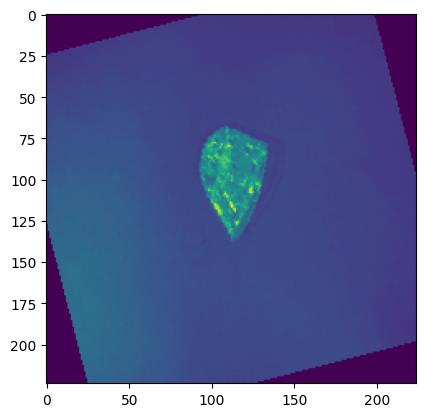

In [27]:
for i in validationSet:

        #-------------------------- TRANSFORMATIONS

        #get first image and label
        imageData = dataset[i][0]
        imageLabel = dataset[i][1]

        #print(imageLabel)
        #print(imageData)

        # [CITED DOCUMENTATION]
        # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
        # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

        #apply vit_transforms
        imageData = vit_transforms(imageData)
        
        plt.imshow(imageData[1,:,:])
        
        
        break
        

In [ ]:
#HP TUNING

#IMPLEMENTED WITH BATCH


MOMENTUM = .8
EPOCHS = 5

learning_rates = [.5,.1,.05,.01,.005,.001,.0005,.0001]




#local_path = "/content/drive/MyDrive/wadaba_local"
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_augmented/images/"
dataset = WadabaData(local_path)
TOTAL_LABELS = 8
BATCH_SIZE = 7




#images that cause errors in the training process
bad_images = [1240,3399]


results = []

for learningRate in learning_rates:
    
    LEARNING_RATE = .00001
    
    #get pretrained weights
    visionTransformerModelWeights = torchvision.models.ViT_B_16_Weights.DEFAULT
    #get associated transforms
    #visionTransformerModelTransforms = torchvision.models.ViT_B_16_Weights.DEFAULT.transforms
    #define model
    #visionTransformerModel = torchvision.models.vit_b_16(weights=visionTransformerModelWeights)
    visionTransformerModel = torchvision.models.vit_l_32()
    #got this idea from EC523 hmrk3 - adjusting output
    visionTransformerModel.heads.head = torch.nn.Linear(in_features=1024,out_features=8)
    visionTransformerModel.to(cudaDevice)
    #declare loss function
    crossEntropyLoss = torch.nn.CrossEntropyLoss()

    #declare optimizer
    #"transfer learning" following the code from slide 105 in lecture "08_Training_II-3.pdf"
    optimizer = torch.optim.Adam(visionTransformerModel.parameters(),lr = LEARNING_RATE)

    
    

    for e in range(EPOCHS):

        print("EPOCH: ----------------------------- ", e,"out of",EPOCHS)
        visionTransformerModel.train()

        for i in range(0,len(trainingSet),BATCH_SIZE):


            #print("Epoch Progress: ",i/len(trainingSet))

            batch = []
            batch_labels = []
            for j in range(0,BATCH_SIZE):

                #-------------------------- TRANSFORMATIONS

                #[CITED DOCUMENTATION]
                #looked up how to implement a "try" and "Except" workflow
                #https://www.w3schools.com/python/python_try_except.asp
                try:
                    #get first image and label
                    imageData = dataset[trainingSet[i+j]][0]
                    imageLabel = dataset[trainingSet[i+j]][1]



                    #print("Training Image Index: ",trainingSet[i+j])

                    #print(imageData)

                    # [CITED DOCUMENTATION]
                    # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                    # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                    #apply vit_transforms
                    imageData = vit_transforms(imageData)

                    '''
                    #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                    imageData = np.array(imageData)
                    height = image.shape[0]
                    width = image.shape[1]
                    layers = image.shape[2]
                    image = image.reshape(layers, height,width)
                    '''

                    # [CITED DOCUMENATION]
                    #needed to convert tensor to numpy
                    #https://docs.pytorch.org/docs/stable/generated/torch.Tensor.numpy.html
                    batch.append(imageData.numpy())
                    batch_labels.append(imageLabel.numpy())

                except:
                    None

            
            batch = np.array(batch)
            batch_labels = np.array(batch_labels)

            #print(batch)
            #print(batch_labels)

            #convert to tensor
            imageData = torch.Tensor(batch).to(cudaDevice)



            #additional transformation
            #imageData = imageData.unsqueeze(0)
            imageData = imageData.float()


            #print(torch.Tensor.type(imageData))

            #print(imageData)
            #print(imageData.shape)








        #-------------------------- FORWARD/BACKWARD PASSES


            #print('output')

            output = visionTransformerModel(imageData)
            #prediction = torch.nn.functional.softmax(output)
            prediction = output

            #print(prediction)

            #[CITED DOCUMENTATION]
            # https://piazza.com/class/mkcrybcxyxq2ep/post/21

            #one hot label created similar to how Weicheng showed us
            imageLabelOneHot = torch.Tensor(np.eye(TOTAL_LABELS)[batch_labels]).to(cudaDevice)

            #print(imageLabelOneHot.shape)
            #print(prediction.shape)

            #print(imageLabelOneHot)

            #L1 optimization
            #I remember referring to this article to see how to implement regularization in pytorch code: https://medium.com/@arthur.lagacherie/understand-l1-and-l2-regularization-through-pytorch-code-ece84fe42ada
            loss = crossEntropyLoss(imageLabelOneHot,prediction) + learningRate*sum(sum(abs(visionTransformerModel.heads.head.weight)))
            #print(loss)
            
            #print(torch.sum(torch.abs(visionTransformerModel.heads.head.parameters())))


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        #print(visionTransformerModel.heads.head.weight)
        #print('done')
        correct = 0
        visionTransformerModel.eval()

        for i in validationSet:

            try: 
                #-------------------------- TRANSFORMATIONS

                #get first image and label
                imageData = dataset[i][0]
                imageLabel = dataset[i][1]

                #print(imageLabel)
                #print(imageData)

                # [CITED DOCUMENTATION]
                # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                #apply vit_transforms
                imageData = vit_transforms(imageData)

                '''
                #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                imageData = np.array(imageData)
                height = image.shape[0]
                width = image.shape[1]
                layers = image.shape[2]
                image = image.reshape(layers, height,width)
                '''

                #convert to tensor
                imageData = torch.Tensor(imageData).to(cudaDevice)

                #additional transformation
                imageData = imageData.unsqueeze(0)
                imageData = imageData.float()

                #print(torch.Tensor.type(imageData))

                #print(imageData.shape)



                #-------------------------- FORWARD/BACKWARD PASSES


                #print('output')
                output = visionTransformerModel(imageData)
                prediction = torch.nn.functional.softmax(output)

                #[CITED DOCUMENTATION]
                # https://piazza.com/class/mkcrybcxyxq2ep/post/21


                if imageLabel.item() == torch.argmax(prediction).item():
                    correct += 1

                #print(imageLabel.item(),torch.argmax(prediction).item())

            except:
                None


        print(learningRate,e,(correct/len(validationSet)))
        results.append([learningRate,e,(correct/len(validationSet))])
        
        print(np.array(results))







print('end of training')








EPOCH: -----------------------------  0 out of 5


In [19]:
print(sum(sum(abs(visionTransformerModel.heads.head.weight))))

tensor(112.2554, device='cuda:0', grad_fn=<AddBackward0>)


In [7]:
test = WadabaData("/projectnb/ec523/projects/finalProjectPlastic/0_Data/NewImages/")


(<PIL.Image.Image image mode=RGB size=4032x3024 at 0x14CD358CF3A0>, tensor(1))
(<PIL.Image.Image image mode=RGB size=4032x3024 at 0x14CD359600D0>, tensor(5))
(<PIL.Image.Image image mode=RGB size=4032x3024 at 0x14CD35963430>, tensor(5))
(<PIL.Image.Image image mode=RGB size=4032x3024 at 0x14CD359600D0>, tensor(5))
(<PIL.Image.Image image mode=RGB size=4032x3024 at 0x14CD35960310>, tensor(1))
(<PIL.Image.Image image mode=RGB size=3759x2743 at 0x14CD35A363B0>, tensor(2))
(<PIL.Image.Image image mode=RGB size=4032x3024 at 0x14CD359600D0>, tensor(1))
(<PIL.Image.Image image mode=RGB size=2640x1528 at 0x14CD35A363B0>, tensor(1))
(<PIL.Image.Image image mode=RGB size=3542x2808 at 0x14CD35963430>, tensor(5))
(<PIL.Image.Image image mode=RGB size=4032x3024 at 0x14CD359600D0>, tensor(2))
(<PIL.Image.Image image mode=RGB size=4032x3024 at 0x14CD35963430>, tensor(2))
(<PIL.Image.Image image mode=RGB size=4032x3024 at 0x14CD35960310>, tensor(2))


In [6]:
# TRAINING HALF WITH NEW IMAGES AND HALF WITH OLD AND TESTING ON COLLECTED IMAGES

#HP TUNING - BATCHES CONVERTED TO TENSORS

#IMPLEMENTED WITH BATCH


cudaDevice = torch.device('cuda')

MOMENTUM = .8
EPOCHS = 20

#learning_rates = [.000001,.000005,.00001,.00005,.0001,.0005,.001,.005]

learning_rates = [1.00e-05]





local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_augmented/images/"
local_path_ORIGINAL = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local/"
TOTAL_LABELS = 8
BATCH_SIZE = 7




#images that cause errors in the training process
bad_images = [1240,3399]


results = []

for learningRate in learning_rates:
    
    #LEARNING_RATE = .00001
    LEARNING_RATE = learningRate
    
    #get pretrained weights
    #visionTransformerModelWeights = torchvision.models.ViT_B_16_Weights.DEFAULT
    #get associated transforms
    #visionTransformerModelTransforms = torchvision.models.ViT_B_16_Weights.DEFAULT.transforms
    #define model
    #visionTransformerModel = torchvision.models.vit_b_16(weights=visionTransformerModelWeights)
    visionTransformerModel = torchvision.models.vit_b_16()
    #got this idea from EC523 hmrk3 - adjusting output
    visionTransformerModel.heads.head = torch.nn.Linear(in_features=768,out_features=8)
    
    #declare loss function
    crossEntropyLoss = torch.nn.CrossEntropyLoss()

    #declare optimizer
    #"transfer learning" following the code from slide 105 in lecture "08_Training_II-3.pdf"
    optimizer = torch.optim.Adam(visionTransformerModel.parameters(),lr = LEARNING_RATE)

    
    visionTransformerModel.to(cudaDevice)

    for e in range(EPOCHS):
        
        if e>9:
            dataset = WadabaData(local_path)
        else:
            dataset = WadabaData(local_path_ORIGINAL)

        print("EPOCH: ----------------------------- ", e,"out of",EPOCHS)
        visionTransformerModel.train()

        for i in range(0,len(trainingSet),BATCH_SIZE):


            #print("Epoch Progress: ",i/len(trainingSet))

            batch = torch.tensor([]).to(cudaDevice)
            batch_labels = torch.tensor([]).to(cudaDevice)
            for j in range(0,BATCH_SIZE):

                try:
                    #-------------------------- TRANSFORMATIONS

                    #[CITED DOCUMENTATION]
                    #looked up how to implement a "try" and "Except" workflow
                    #https://www.w3schools.com/python/python_try_except.asp

                    #get first image and label
                    imageData = dataset[trainingSet[i+j]][0]
                    imageLabel = dataset[trainingSet[i+j]][1]





                    #print("Training Image Index: ",trainingSet[i+j])

                    #print(imageData)

                    # [CITED DOCUMENTATION]
                    # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                    # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                    #apply vit_transforms
                    imageData = vit_transforms(imageData).to(cudaDevice)
                    imageLabel = torch.Tensor([imageLabel]).to(cudaDevice)




                    '''
                    #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                    imageData = np.array(imageData)
                    height = image.shape[0]
                    width = image.shape[1]
                    layers = image.shape[2]
                    image = image.reshape(layers, height,width)
                    '''

                    # [CITED DOCUMENATION]
                    #needed to convert tensor to numpy
                    #https://docs.pytorch.org/docs/stable/generated/torch.Tensor.numpy.html

                    #use torch.cat
                    batch = torch.cat((batch,imageData.unsqueeze(0)),0)
                    batch_labels = torch.cat((batch_labels,imageLabel),0)




                    #batch.append(imageData.numpy())
                    #batch_labels.append(imageLabel.numpy())
                except:
                    None

  

            
            #batch = np.array(batch)
            #batch_labels = np.array(batch_labels)

            #print(batch)
            #print(batch_labels)

            #convert to tensor
            imageData = torch.Tensor(batch).to(cudaDevice)

            

            #additional transformation
            #imageData = imageData.unsqueeze(0)
            imageData = imageData.float()


            #print(torch.Tensor.type(imageData))

            #print(imageData)
            #print(imageData.shape)
            
            #redefined the "dtype" attribute to an integer as shown in this documentation: https://docs.pytorch.org/docs/stable/tensor_attributes.html
            batch_labels = torch.tensor(batch_labels,dtype=torch.int)








        #-------------------------- FORWARD/BACKWARD PASSES


            #print('output')

            output = visionTransformerModel(imageData)
            #prediction = torch.nn.functional.softmax(output)
            prediction = output


            #[CITED DOCUMENTATION]
            # https://piazza.com/class/mkcrybcxyxq2ep/post/21

            #one hot label created similar to how Weicheng showed us
            
            #using torch.eye
            #https://docs.pytorch.org/docs/stable/generated/torch.eye.html
            identity = torch.eye(TOTAL_LABELS).to(cudaDevice)
            imageLabelOneHot = identity[batch_labels]

            #print(imageLabelOneHot.shape)
            #print(prediction.shape)


            #L1 optimization
            #I remember referring to this article to see how to implement regularization in pytorch code: https://medium.com/@arthur.lagacherie/understand-l1-and-l2-regularization-through-pytorch-code-ece84fe42ada
            loss = crossEntropyLoss(prediction,imageLabelOneHot) + 5e-3*sum(sum(abs(visionTransformerModel.heads.head.weight)))
            print(loss)
            
            #print(torch.sum(torch.abs(visionTransformerModel.heads.head.parameters())))


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        #print(visionTransformerModel.heads.head.weight)
        #print('done')
        correct = 0
        total = 0
        visionTransformerModel.eval()

        for i in validationSet:

            try: 
                #-------------------------- TRANSFORMATIONS

                #get first image and label
                imageData = dataset[i][0]
                imageLabel = dataset[i][1]

                #print(imageLabel)
                #print(imageData)

                # [CITED DOCUMENTATION]
                # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                #apply vit_transforms
                imageData = vit_transforms(imageData)

                '''
                #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                imageData = np.array(imageData)
                height = image.shape[0]
                width = image.shape[1]
                layers = image.shape[2]
                image = image.reshape(layers, height,width)
                '''

                #convert to tensor
                imageData = torch.Tensor(imageData).to(cudaDevice)

                #additional transformation
                imageData = imageData.unsqueeze(0)
                imageData = imageData.float()

                #print(torch.Tensor.type(imageData))

                #print(imageData.shape)



                #-------------------------- FORWARD/BACKWARD PASSES


                #print('output')
                output = visionTransformerModel(imageData)
                prediction = torch.nn.functional.softmax(output)

                #[CITED DOCUMENTATION]
                # https://piazza.com/class/mkcrybcxyxq2ep/post/21


                if imageLabel.item() == torch.argmax(prediction).item():
                    correct += 1
                
                total+=1

                print(imageLabel.item(),torch.argmax(prediction).item())

            except:
                None


        print(learningRate,e,(correct/total))
        results.append([learningRate,e,(correct/total)])
        
        print(np.array(results))







print('end of training')



#TEST PROCEDURE


correct = 0
visionTransformerModel.eval()

for i in testingSet:
    
    try:

        #-------------------------- TRANSFORMATIONS

        #get first image and label
        imageData = dataset[i][0]
        imageLabel = dataset[i][1]

        #print(imageLabel)
        #print(imageData)

        # [CITED DOCUMENTATION]
        # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
        # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

        #apply vit_transforms
        imageData = vit_transforms(imageData)

        '''
        #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
        imageData = np.array(imageData)
        height = image.shape[0]
        width = image.shape[1]
        layers = image.shape[2]
        image = image.reshape(layers, height,width)
        '''

        #convert to tensor
        imageData = torch.Tensor(imageData).to(cudaDevice)

        #additional transformation
        imageData = imageData.unsqueeze(0)
        imageData = imageData.float()

        #print(torch.Tensor.type(imageData))



        #-------------------------- FORWARD/BACKWARD PASSES


        #print('output')
        output = visionTransformerModel(imageData)
        prediction = torch.nn.functional.softmax(output)

        #[CITED DOCUMENTATION]
        # https://piazza.com/class/mkcrybcxyxq2ep/post/21


        if imageLabel.item() == torch.argmax(prediction).item():
            correct += 1

        print(imageLabel.item(),torch.argmax(prediction).item())
    
    except:
        None


print('test accuracy')
        
print(correct/len(testingSet))






correct = 0
visionTransformerModel.eval()

for i in range(37):
    
    try:

        #-------------------------- TRANSFORMATIONS

        dataset = WadabaData("/projectnb/ec523/projects/finalProjectPlastic/0_Data/NewImages/")
        #get first image and label
        imageData = dataset[i][0]
        imageLabel = dataset[i][1]

        #print(imageLabel)
        #print(imageData)

        # [CITED DOCUMENTATION]
        # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
        # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

        #apply vit_transforms
        imageData = vit_transforms(imageData)

        '''
        #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
        imageData = np.array(imageData)
        height = image.shape[0]
        width = image.shape[1]
        layers = image.shape[2]
        image = image.reshape(layers, height,width)
        '''

        #convert to tensor
        imageData = torch.Tensor(imageData).to(cudaDevice)

        #additional transformation
        imageData = imageData.unsqueeze(0)
        imageData = imageData.float()

        #print(torch.Tensor.type(imageData))



        #-------------------------- FORWARD/BACKWARD PASSES


        #print('output')
        output = visionTransformerModel(imageData)
        prediction = torch.nn.functional.softmax(output)

        #[CITED DOCUMENTATION]
        # https://piazza.com/class/mkcrybcxyxq2ep/post/21


        if imageLabel.item() == torch.argmax(prediction).item():
            correct += 1

        print(imageLabel.item(),torch.argmax(prediction).item())
    
    except:
        None

        
print(correct)



EPOCH: -----------------------------  0 out of 20


/scratch/4661501.1.ece/ipykernel_3479713/2346382380.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch_labels = torch.tensor(batch_labels,dtype=torch.int)


tensor(3.0266, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.2669, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3098, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.9748, device='cuda:0', grad_fn=<AddBackward0>)
tensor(3.6445, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3532, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.0853, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.7665, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.6608, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.7988, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.1384, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.5903, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.9458, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.5916, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3517, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.8435, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.7375, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.7359, device='cuda:0', grad_fn=<AddBack

tensor(1.5230, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.1251, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2531, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.5795, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.5864, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0443, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.0466, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.5714, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.8221, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.9274, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.2914, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.8892, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.9739, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.7063, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.4776, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3642, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.7895, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.8470, device='cuda:0', grad_fn=<AddBack

tensor(1.8205, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.0135, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.1141, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2295, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.4457, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3382, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3796, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.6325, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.4504, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.1315, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.6436, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.4813, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.5140, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0432, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.8463, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.3672, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.5299, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.5942, device='cuda:0', grad_fn=<AddBack

...

tensor(1.6496, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8664, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.7056, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2412, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.7188, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.1055, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8929, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9619, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3821, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.3567, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.7265, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8710, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2362, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0053, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2186, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.9382, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.5768, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2087, device='cuda:0', grad_fn=<AddBack

/scratch/4661501.1.ece/ipykernel_3479713/2346382380.py:339: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prediction = torch.nn.functional.softmax(output)


1 1
6 2
2 2
1 1
2 2
6 6
1 1
5 1
6 6
1 1
1 1
6 1
6 1
6 2
1 1
5 1
6 1
1 1
5 6
5 2
1 1
2 2
2 5
6 2
2 6
1 1
1 1
1 2
1 1
1 1
6 6
1 1
5 1
5 1
1 2
5 1
5 1
6 1
1 1
1 1
1 1
1 1
1 1
6 1
1 5
1 1
1 1
5 1
5 1
2 1
6 6
1 1
5 1
2 1
1 2
1 1
6 1
1 2
6 1
5 2
1 1
1 1
1 2
1 1
1 1
2 2
1 1
1 1
5 2
1 1
5 1
6 1
5 1
2 2
1 1
6 1
1 1
1 1
1 1
2 1
2 2
5 6
1 1
6 1
1 1
1 1
2 1
5 2
5 1
6 2
2 2
1 1
6 1
6 6
6 1
5 6
1 1
1 1
5 1
2 5
1 1
5 6
1 1
1 2
5 5
2 2
6 1
1 1
6 1
1 1
2 1
5 1
6 6
1 1
1 1
1 1
2 6
1 2
1 1
5 2
1 1
5 1
1 1
1 1
7 1
6 5
1 2
2 1
1 1
1 1
5 1
2 2
2 2
6 6
5 2
1 1
2 2
1 1
2 1
1 2
2 1
1 1
1 2
2 1
1 1
2 1
1 1
6 1
1 1
1 1
1 1
1 1
1 1
5 1
5 1
2 2
5 2
6 2
2 2
6 2
1 1
6 2
1 1
2 2
6 1
6 6
1 1
2 2
1 1
1 1
6 2
1 1
1 1
1 1
2 1
1 1
2 2
2 2
1 1
1 1
5 6
1 1
1 1
5 1
5 5
1 1
2 1
1 2
1 1
6 6
1 1
2 1
1 1
1 1
1 1
6 5
1 1
1 1
2 2
2 2
1 2
1 1
2 2
2 1
1 1
5 1
1 1
2 2
1 1
1 2
1 2
1 1
1 1
5 6
1 1
1 1
1 1
1 1
1 1
5 6
5 1
2 1
1 2
5 1
1 1
5 1
1 1
2 2
2 1
5 1
2 1
2 5
1 1
6 6
1 1
5 2
1 1
6 1
6 6
7 1
1 1
1 1
5 2
1 1
1 2
6 1
1 1
1 1
1 1
1 1


/scratch/4661501.1.ece/ipykernel_3479713/2346382380.py:412: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prediction = torch.nn.functional.softmax(output)


1 2
1 1
1 6
5 1
1 1
5 6
2 2
4 1
5 1
5 6
1 1
2 1
4 1
4 2
2 1
4 1
4 1
1 1
1 1
2 6
1 6
2 1
1 1
5 5
2 6
5 1
2 1
5 2
2 2
5 2
5 1
1 1
2 6
4 1
2 2
5 1
1 1
12


In [7]:

#TEST PROCEDURE

dataset = WadabaData("/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local/")

correct = 0
visionTransformerModel.eval()

for i in testingSet:
    
    try:

        #-------------------------- TRANSFORMATIONS

        #get first image and label
        imageData = dataset[i][0]
        imageLabel = dataset[i][1]

        #print(imageLabel)
        #print(imageData)

        # [CITED DOCUMENTATION]
        # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
        # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

        #apply vit_transforms
        imageData = vit_transforms(imageData)

        '''
        #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
        imageData = np.array(imageData)
        height = image.shape[0]
        width = image.shape[1]
        layers = image.shape[2]
        image = image.reshape(layers, height,width)
        '''

        #convert to tensor
        imageData = torch.Tensor(imageData).to(cudaDevice)

        #additional transformation
        imageData = imageData.unsqueeze(0)
        imageData = imageData.float()

        #print(torch.Tensor.type(imageData))



        #-------------------------- FORWARD/BACKWARD PASSES


        #print('output')
        output = visionTransformerModel(imageData)
        prediction = torch.nn.functional.softmax(output)

        #[CITED DOCUMENTATION]
        # https://piazza.com/class/mkcrybcxyxq2ep/post/21


        if imageLabel.item() == torch.argmax(prediction).item():
            correct += 1

        print(imageLabel.item(),torch.argmax(prediction).item())
    
    except:
        None


print('test accuracy')
        
print(correct/len(testingSet))






/scratch/4661501.1.ece/ipykernel_3479713/2386067225.py:53: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prediction = torch.nn.functional.softmax(output)


1 1
1 5
5 5
5 5
2 5
1 1
2 2
6 6
2 2
1 1
2 2
5 2
6 5
1 1
5 7
7 7
1 1
1 1
2 2
1 2
6 5
1 1
6 6
2 2
1 1
5 1
6 5
1 1
5 5
6 5
5 5
1 1
2 2
2 6
6 2
2 2
1 1
1 1
1 6
1 1
1 1
1 1
6 5
1 1
5 5
1 1
1 1
6 6
1 2
5 2
2 2
1 1
2 2
1 1
5 5
2 6
1 1
1 1
1 1
5 5
1 2
1 1
1 1
1 1
1 1
1 1
1 1
1 1
5 1
2 1
6 6
1 1
5 5
2 2
6 5
1 1
6 5
1 1
5 1
6 6
5 1
6 5
5 1
1 1
6 6
1 2
5 5
1 1
6 6
1 1
1 1
5 5
1 1
1 1
5 1
1 1
1 1
1 1
1 1
1 1
5 5
1 1
1 1
1 1
5 5
2 2
2 2
2 2
1 1
6 5
1 1
6 5
1 1
1 1
1 5
2 1
1 1
5 5
2 5
1 1
1 1
5 5
1 1
1 1
6 5
1 1
1 1
2 2
5 5
5 5
6 6
2 2
1 1
2 2
6 1
6 6
5 5
1 1
1 1
6 6
1 1
5 5
2 5
6 6
6 6
1 1
1 1
5 5
1 1
1 1
1 6
5 5
1 1
6 5
1 1
1 1
1 1
1 1
6 5
1 1
5 1
1 1
1 1
6 6
1 1
2 2
6 1
2 2
1 1
1 1
5 5
1 1
5 1
6 6
1 1
1 1
1 1
1 1
6 6
1 1
2 2
2 2
1 1
1 1
1 1
1 1
1 1
6 5
1 1
1 1
1 2
1 1
2 2
2 2
6 5
1 5
1 1
2 2
1 1
2 1
1 1
6 5
1 1
1 1
1 2
2 2
1 1
2 1
2 1
6 5
1 1
1 1
1 1
1 1
1 1
5 5
5 5
2 1
5 5
6 6
2 2
6 6
1 1
5 5
6 6
1 2
1 1
2 2
6 1
5 5
2 1
1 1
2 2
1 1
1 1
1 1
1 1
5 2
1 1
1 1
2 2
1 1
2 2
2 2
6 6
5 6
1 2
1 1
6 1
5 5


In [8]:
results = np.array([[1, 2],
[1, 1],
[1, 6],
[5, 1],
[1, 1],
[5, 6],
[2, 2],
[4, 1],
[5, 1],
[5, 6],
[1, 1],
[2, 1],
[4, 1],
[4, 2],
[2, 1],
[4, 1],
[4, 1],
[1, 1],
[1, 1],
[2, 6],
[1, 6],
[2, 1],
[1, 1],
[5, 5],
[2, 6],
[5, 1],
[2, 1],
[5, 2],
[2, 2],
[5, 2],
[5, 1],
[1, 1],
[2, 6],
[4, 1],
[2, 2],
[5, 1],
[1, 1]])


finalResults = []
for j in range(0,8):
    rowArray = []
    for i in range(0,8):
        count = 0
        for n in results:
            if n[0] == j:
                if n[1] == i:
                    count+=1
        rowArray.append(count)
    #print(rowArray)
    
    finalResults.append(rowArray)

    
print(np.array(finalResults))
        

[[0 0 0 0 0 0 0 0]
 [0 8 1 0 0 0 2 0]
 [0 4 3 0 0 0 3 0]
 [0 0 0 0 0 0 0 0]
 [0 5 1 0 0 0 0 0]
 [0 5 2 0 0 1 2 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


In [7]:




correct = 0
visionTransformerModel.eval()

for i in range(37):
    

        #-------------------------- TRANSFORMATIONS

        dataset = WadabaData("/projectnb/ec523/projects/finalProjectPlastic/0_Data/NewImages/")
        #get first image and label
        imageData = dataset[i][0]
        imageLabel = dataset[i][1]

        #print(imageLabel)
        #print(imageData)

        # [CITED DOCUMENTATION]
        # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
        # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

        #apply vit_transforms
        imageData = vit_transforms(imageData)

        '''
        #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
        imageData = np.array(imageData)
        height = image.shape[0]
        width = image.shape[1]
        layers = image.shape[2]
        image = image.reshape(layers, height,width)
        '''

        #convert to tensor
        imageData = torch.Tensor(imageData).to(cudaDevice)

        #additional transformation
        imageData = imageData.unsqueeze(0)
        imageData = imageData.float()

        #print(torch.Tensor.type(imageData))



        #-------------------------- FORWARD/BACKWARD PASSES


        #print('output')
        output = visionTransformerModel(imageData)
        prediction = torch.nn.functional.softmax(output)

        #[CITED DOCUMENTATION]
        # https://piazza.com/class/mkcrybcxyxq2ep/post/21


        if imageLabel.item() == torch.argmax(prediction).item():
            correct += 1

        print(imageLabel.item(),torch.argmax(prediction).item())
    

        
print(correct)

/scratch/4631945.1.ece/ipykernel_3795822/1920540046.py:49: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prediction = torch.nn.functional.softmax(output)


1 1
1 1
1 1
5 1
1 1
5 2
2 2
4 1
5 1
5 6
1 1
2 1
4 1
4 1
2 1
4 1
4 1
1 1
1 1
2 2
1 2
2 1
1 1
5 1
2 2
5 1
2 1
5 1
2 2
5 1
5 1
1 1
2 2
4 1
2 1
5 1
1 1
15


Text(0, 0.5, 'Validation Accuracy')

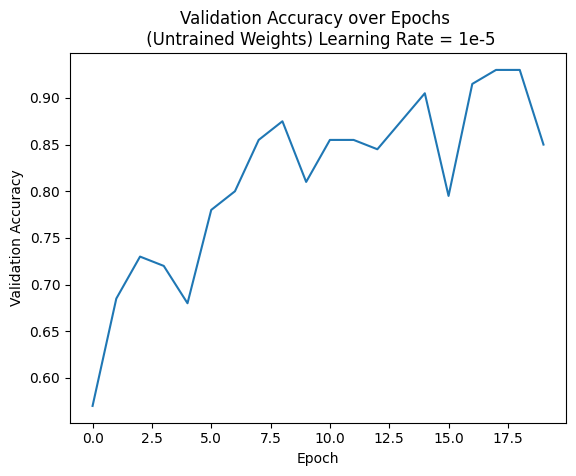

In [13]:
#Validation accuracy on untrained weights

results = np.array([[1.00e-05, 0.00e+00, 5.70e-01],
 [1.00e-05, 1.00e+00, 6.85e-01],
 [1.00e-05, 2.00e+00, 7.30e-01],
 [1.00e-05, 3.00e+00, 7.20e-01],
 [1.00e-05, 4.00e+00, 6.80e-01],
 [1.00e-05, 5.00e+00, 7.80e-01],
 [1.00e-05, 6.00e+00, 8.00e-01],
 [1.00e-05, 7.00e+00, 8.55e-01],
 [1.00e-05, 8.00e+00, 8.75e-01],
 [1.00e-05, 9.00e+00, 8.10e-01],
 [1.00e-05, 1.00e+01, 8.55e-01],
 [1.00e-05, 1.10e+01, 8.55e-01],
 [1.00e-05, 1.20e+01, 8.45e-01],
 [1.00e-05, 1.30e+01, 8.75e-01],
 [1.00e-05, 1.40e+01, 9.05e-01],
 [1.00e-05, 1.50e+01, 7.95e-01],
 [1.00e-05, 1.60e+01, 9.15e-01],
 [1.00e-05, 1.70e+01, 9.30e-01],
 [1.00e-05, 1.80e+01, 9.30e-01],
 [1.00e-05, 1.90e+01, 8.50e-01]])

plt.plot(results[:,1],results[:,2])
plt.title('Validation Accuracy over Epochs \n (Untrained Weights) Learning Rate = 1e-5')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')

[[1.00e-06 4.00e+00 6.55e-01]
 [5.00e-06 4.00e+00 7.40e-01]
 [1.00e-05 4.00e+00 7.60e-01]
 [5.00e-05 4.00e+00 7.35e-01]
 [1.00e-04 4.00e+00 6.85e-01]
 [5.00e-04 4.00e+00 5.30e-01]
 [1.00e-03 4.00e+00 5.30e-01]]


Text(0, 0.5, 'Validation Accuracy')

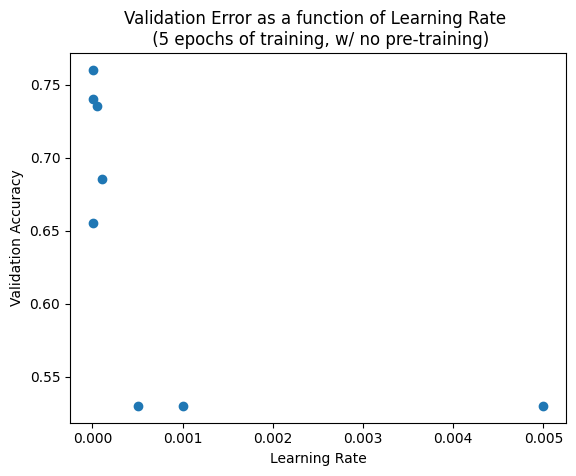

In [4]:
#HP tuning - learning rate untrained weights vit_B_16

results = np.array([[1.00e-06, 0.00e+00, 5.35e-01],
 [1.00e-06, 1.00e+00, 5.90e-01],
 [1.00e-06, 2.00e+00, 6.55e-01],
 [1.00e-06, 3.00e+00, 6.65e-01],
 [1.00e-06, 4.00e+00, 6.55e-01],
 [5.00e-06, 0.00e+00, 6.15e-01],
 [5.00e-06, 1.00e+00, 6.40e-01],
 [5.00e-06, 2.00e+00, 6.50e-01],
 [5.00e-06, 3.00e+00, 7.15e-01],
 [5.00e-06, 4.00e+00, 7.40e-01],
 [1.00e-05, 0.00e+00, 6.05e-01],
 [1.00e-05, 1.00e+00, 6.55e-01],
 [1.00e-05, 2.00e+00, 7.10e-01],
 [1.00e-05, 3.00e+00, 7.40e-01],
 [1.00e-05, 4.00e+00, 7.60e-01],
 [5.00e-05, 0.00e+00, 5.65e-01],
 [5.00e-05, 1.00e+00, 6.80e-01],
 [5.00e-05, 2.00e+00, 6.75e-01],
 [5.00e-05, 3.00e+00, 6.35e-01],
 [5.00e-05, 4.00e+00, 7.35e-01],
 [1.00e-04, 0.00e+00, 5.60e-01],
 [1.00e-04, 1.00e+00, 5.35e-01],
 [1.00e-04, 2.00e+00, 6.35e-01],
 [1.00e-04, 3.00e+00, 6.25e-01],
 [1.00e-04, 4.00e+00, 6.85e-01],
 [5.00e-04, 0.00e+00, 5.30e-01],
 [5.00e-04, 1.00e+00, 5.05e-01],
 [5.00e-04, 2.00e+00, 5.30e-01],
 [5.00e-04, 3.00e+00, 5.30e-01],
 [5.00e-04, 4.00e+00, 5.30e-01],
 [1.00e-03, 0.00e+00, 5.30e-01],
 [1.00e-03, 1.00e+00, 5.30e-01],
 [1.00e-03, 2.00e+00, 5.30e-01],
 [1.00e-03, 3.00e+00, 4.90e-01],
 [1.00e-03, 4.00e+00, 5.30e-01],
 [5.00e-03, 0.00e+00, 5.30e-01],
 [5.00e-03, 1.00e+00, 5.30e-01],
 [5.00e-03, 2.00e+00, 5.30e-01],
 [5.00e-03, 3.00e+00, 5.30e-01],
 [5.00e-03, 4.00e+00, 5.30e-01]])

resultsData = results[results[:,1] == 4,:]

print(resultsData[:-1,:])
plt.scatter(resultsData[:,0],resultsData[:,2])
plt.title('Validation Error as a function of Learning Rate \n (5 epochs of training, w/ no pre-training)')
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')

In [50]:
results2 = np.array(results)

#print(results2)
#print(results1)

results3 = np.concatenate((results1,results2),axis=0)

print(results3)

[[1.00000000e-01 0.00000000e+00 2.26666667e-01]
 [1.00000000e-01 1.00000000e+00 2.36666667e-01]
 [1.00000000e-01 2.00000000e+00 2.26666667e-01]
 [1.00000000e-01 3.00000000e+00 2.40000000e-01]
 [1.00000000e-01 4.00000000e+00 2.36666667e-01]
 [1.00000000e-02 0.00000000e+00 2.36666667e-01]
 [1.00000000e-02 1.00000000e+00 2.35000000e-01]
 [1.00000000e-02 2.00000000e+00 2.35000000e-01]
 [1.00000000e-02 3.00000000e+00 2.45000000e-01]
 [1.00000000e-02 4.00000000e+00 2.38333333e-01]
 [1.00000000e-03 0.00000000e+00 2.18333333e-01]
 [1.00000000e-03 1.00000000e+00 2.31666667e-01]
 [1.00000000e-03 2.00000000e+00 2.35000000e-01]
 [1.00000000e-03 3.00000000e+00 2.31666667e-01]
 [1.00000000e-03 4.00000000e+00 2.38333333e-01]
 [1.00000000e-04 0.00000000e+00 7.50000000e-02]
 [1.00000000e-04 1.00000000e+00 1.60000000e-01]
 [1.00000000e-04 2.00000000e+00 1.88333333e-01]
 [1.00000000e-04 3.00000000e+00 2.06666667e-01]
 [1.00000000e-04 4.00000000e+00 2.11666667e-01]
 [5.00000000e-01 0.00000000e+00 2.250000

In [6]:
#HP TUNING - BATCHES CONVERTED TO TENSORS - BOTTLENECK TO LINEAR LAYERS

#IMPLEMENTED WITH BATCH


cudaDevice = torch.device('cuda')

MOMENTUM = .8
EPOCHS = 20

#learning_rates = [.000001,.000005,.00001,.00005,.0001,.0005,.001,.005]

learning_rates = [1.00e-05]




#local_path = "/content/drive/MyDrive/wadaba_local"
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local"
dataset = WadabaData(local_path)
TOTAL_LABELS = 8
BATCH_SIZE = 7




#images that cause errors in the training process
bad_images = [1240,3399]


results = []

for learningRate in learning_rates:
    
    #LEARNING_RATE = .00001
    LEARNING_RATE = learningRate
    
    #get pretrained weights
    #visionTransformerModelWeights = torchvision.models.ViT_B_16_Weights.DEFAULT
    #get associated transforms
    #visionTransformerModelTransforms = torchvision.models.ViT_B_16_Weights.DEFAULT.transforms
    #define model
    #visionTransformerModel = torchvision.models.vit_b_16(weights=visionTransformerModelWeights)
    visionTransformerModel = torchvision.models.vit_b_16()
    #got this idea from EC523 hmrk3 - adjusting output
    visionTransformerModel.heads.head = torch.nn.Linear(in_features=768,out_features=8)
    
    #declare loss function
    crossEntropyLoss = torch.nn.CrossEntropyLoss()

    #declare optimizer
    #"transfer learning" following the code from slide 105 in lecture "08_Training_II-3.pdf"
    optimizer = torch.optim.Adam(visionTransformerModel.parameters(),lr = LEARNING_RATE)
    
    visionTransformerModel.encoder.layers.encoder_layer_0.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_0.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.encoder.layers.encoder_layer_1.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_1.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.encoder.layers.encoder_layer_2.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_2.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.encoder.layers.encoder_layer_3.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_3.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.encoder.layers.encoder_layer_4.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_4.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.encoder.layers.encoder_layer_5.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_5.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.encoder.layers.encoder_layer_6.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_6.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.encoder.layers.encoder_layer_7.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_7.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.encoder.layers.encoder_layer_8.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_8.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.encoder.layers.encoder_layer_9.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_9.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.encoder.layers.encoder_layer_10.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_10.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.encoder.layers.encoder_layer_11.mlp[0] = torch.nn.Linear(in_features=768, out_features=10, bias=True)
    visionTransformerModel.encoder.layers.encoder_layer_11.mlp[3] = torch.nn.Linear(in_features=10, out_features=768, bias=True)

    visionTransformerModel.to(cudaDevice)

    for e in range(EPOCHS):

        print("EPOCH: ----------------------------- ", e,"out of",EPOCHS)
        visionTransformerModel.train()

        for i in range(0,len(trainingSet),BATCH_SIZE):


            #print("Epoch Progress: ",i/len(trainingSet))

            batch = torch.tensor([]).to(cudaDevice)
            batch_labels = torch.tensor([]).to(cudaDevice)
            for j in range(0,BATCH_SIZE):

                try:
                    #-------------------------- TRANSFORMATIONS

                    #[CITED DOCUMENTATION]
                    #looked up how to implement a "try" and "Except" workflow
                    #https://www.w3schools.com/python/python_try_except.asp

                    #get first image and label
                    imageData = dataset[trainingSet[i+j]][0]
                    imageLabel = dataset[trainingSet[i+j]][1]





                    #print("Training Image Index: ",trainingSet[i+j])

                    #print(imageData)

                    # [CITED DOCUMENTATION]
                    # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                    # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                    #apply vit_transforms
                    imageData = vit_transforms(imageData).to(cudaDevice)
                    imageLabel = torch.Tensor([imageLabel]).to(cudaDevice)




                    '''
                    #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                    imageData = np.array(imageData)
                    height = image.shape[0]
                    width = image.shape[1]
                    layers = image.shape[2]
                    image = image.reshape(layers, height,width)
                    '''

                    # [CITED DOCUMENATION]
                    #needed to convert tensor to numpy
                    #https://docs.pytorch.org/docs/stable/generated/torch.Tensor.numpy.html

                    #use torch.cat
                    batch = torch.cat((batch,imageData.unsqueeze(0)),0)
                    batch_labels = torch.cat((batch_labels,imageLabel),0)




                    #batch.append(imageData.numpy())
                    #batch_labels.append(imageLabel.numpy())
                except:
                    None

  

            
            #batch = np.array(batch)
            #batch_labels = np.array(batch_labels)

            #print(batch)
            #print(batch_labels)

            #convert to tensor
            imageData = torch.Tensor(batch).to(cudaDevice)

            

            #additional transformation
            #imageData = imageData.unsqueeze(0)
            imageData = imageData.float()


            #print(torch.Tensor.type(imageData))

            #print(imageData)
            #print(imageData.shape)
            
            #redefined the "dtype" attribute to an integer as shown in this documentation: https://docs.pytorch.org/docs/stable/tensor_attributes.html
            batch_labels = torch.tensor(batch_labels,dtype=torch.int)








        #-------------------------- FORWARD/BACKWARD PASSES


            #print('output')

            output = visionTransformerModel(imageData)
            #prediction = torch.nn.functional.softmax(output)
            prediction = output


            #[CITED DOCUMENTATION]
            # https://piazza.com/class/mkcrybcxyxq2ep/post/21

            #one hot label created similar to how Weicheng showed us
            
            #using torch.eye
            #https://docs.pytorch.org/docs/stable/generated/torch.eye.html
            identity = torch.eye(TOTAL_LABELS).to(cudaDevice)
            imageLabelOneHot = identity[batch_labels]

            #print(imageLabelOneHot.shape)
            #print(prediction.shape)


            #L1 optimization
            #I remember referring to this article to see how to implement regularization in pytorch code: https://medium.com/@arthur.lagacherie/understand-l1-and-l2-regularization-through-pytorch-code-ece84fe42ada
            loss = crossEntropyLoss(prediction,imageLabelOneHot) #+ learningRate*sum(sum(abs(visionTransformerModel.heads.head.weight)))
            print(loss)
            
            #print(torch.sum(torch.abs(visionTransformerModel.heads.head.parameters())))


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        #print(visionTransformerModel.heads.head.weight)
        #print('done')
        correct = 0
        total = 0
        visionTransformerModel.eval()

        for i in validationSet:

            try: 
                #-------------------------- TRANSFORMATIONS

                #get first image and label
                imageData = dataset[i][0]
                imageLabel = dataset[i][1]

                #print(imageLabel)
                #print(imageData)

                # [CITED DOCUMENTATION]
                # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                #apply vit_transforms
                imageData = vit_transforms(imageData)

                '''
                #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                imageData = np.array(imageData)
                height = image.shape[0]
                width = image.shape[1]
                layers = image.shape[2]
                image = image.reshape(layers, height,width)
                '''

                #convert to tensor
                imageData = torch.Tensor(imageData).to(cudaDevice)

                #additional transformation
                imageData = imageData.unsqueeze(0)
                imageData = imageData.float()

                #print(torch.Tensor.type(imageData))

                #print(imageData.shape)



                #-------------------------- FORWARD/BACKWARD PASSES


                #print('output')
                output = visionTransformerModel(imageData)
                prediction = torch.nn.functional.softmax(output)

                #[CITED DOCUMENTATION]
                # https://piazza.com/class/mkcrybcxyxq2ep/post/21


                if imageLabel.item() == torch.argmax(prediction).item():
                    correct += 1
                
                total+=1

                print(imageLabel.item(),torch.argmax(prediction).item())

            except:
                None


        print(learningRate,e,(correct/total))
        results.append([learningRate,e,(correct/total)])
        
        print(np.array(results))







print('end of training')




EPOCH: -----------------------------  0 out of 20


/scratch/4290674.1.academic-gpu/ipykernel_3250539/1758545492.py:187: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch_labels = torch.tensor(batch_labels,dtype=torch.int)


tensor(2.1729, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.7133, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.0652, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.4737, device='cuda:0', grad_fn=<DivBackward1>)
tensor(2.2638, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.0288, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.5146, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.9140, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.1347, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.2330, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.7010, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.8189, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.0834, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.0270, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.6640, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.0919, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.1527, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.9171, device='cuda:0', grad_fn=<DivBack

tensor(0.9719, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.5530, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.7466, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.9764, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.0368, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.5913, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.2906, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.9615, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.2006, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.5307, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.5332, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.4248, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.4381, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.8483, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.9329, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.8493, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.0005, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.1931, device='cuda:0', grad_fn=<DivBack

tensor(1.3357, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.5367, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.6767, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.7198, device='cuda:0', grad_fn=<DivBackward1>)
tensor(2.0133, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.8782, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.7945, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.0171, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.8944, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.6614, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.1214, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.9474, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.9648, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.4465, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.3105, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.6663, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.9297, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.2087, device='cuda:0', grad_fn=<DivBack

...

tensor(0.1482, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.6935, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.3353, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.3624, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0576, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1398, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.2699, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0772, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1537, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.3949, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1029, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1997, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0218, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.8907, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1219, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.2818, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.2731, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0034, device='cuda:0', grad_fn=<DivBack

tensor(0.3891, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.4106, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.2292, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.7822, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.2600, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0499, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1435, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1348, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.2098, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.3714, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1995, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1072, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0353, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0803, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1181, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0529, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1134, device='cuda:0', grad_fn=<DivBackward1>)
tensor(1.1072, device='cuda:0', grad_fn=<DivBack

tensor(0.0878, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.2977, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1312, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.7269, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0221, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0776, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1637, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1055, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1196, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1186, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.6530, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1689, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1324, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1089, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.4077, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0670, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.2985, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1552, device='cuda:0', grad_fn=<DivBack

tensor(0.4997, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0869, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0463, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0583, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.4225, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.2675, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0192, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0419, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1911, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.3224, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0073, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0941, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0453, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1392, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0396, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1088, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.3438, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0162, device='cuda:0', grad_fn=<DivBack

tensor(0.0221, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0321, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0455, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.2723, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1015, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.3060, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.2081, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0596, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0532, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.4033, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1588, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.7493, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0333, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0181, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.0552, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1287, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1239, device='cuda:0', grad_fn=<DivBackward1>)
tensor(0.1236, device='cuda:0', grad_fn=<DivBack

[[1.00000000e-01 4.00000000e+00 2.36666667e-01]
 [1.00000000e-02 4.00000000e+00 2.38333333e-01]
 [1.00000000e-03 4.00000000e+00 2.38333333e-01]
 [1.00000000e-04 4.00000000e+00 2.11666667e-01]
 [5.00000000e-01 4.00000000e+00 2.41666667e-01]
 [5.00000000e-02 4.00000000e+00 2.38333333e-01]
 [5.00000000e-03 4.00000000e+00 2.30000000e-01]]


Text(0, 0.5, 'Validation Accuracy')

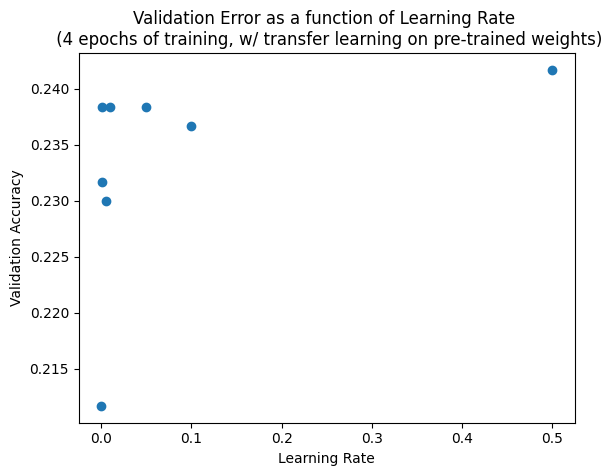

In [80]:
'''

lr, epoch#-starting at 0, validation accuracy
results = [[1.00000000e-01 4.00000000e+00 2.36666667e-01],
 [1.00000000e-02 4.00000000e+00 2.38333333e-01],
 [1.00000000e-03 4.00000000e+00 2.38333333e-01],
 [1.00000000e-04 4.00000000e+00 2.11666667e-01],
 [5.00000000e-01 4.00000000e+00 2.41666667e-01],
 [5.00000000e-02 4.00000000e+00 2.38333333e-01],
 [5.00000000e-03 4.00000000e+00 2.30000000e-01]]
 '''

resultsData = results3[results3[:,1] == 4,:]

print(resultsData[:-1,:])
plt.scatter(resultsData[:,0],resultsData[:,2])
plt.title('Validation Error as a function of Learning Rate \n (4 epochs of training, w/ transfer learning on pre-trained weights)')
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')

[[5.00000000e-01 4.00000000e+00 1.76666667e-01]
 [1.00000000e-01 4.00000000e+00 2.51666667e-01]
 [5.00000000e-02 4.00000000e+00 2.48333333e-01]
 [1.00000000e-02 4.00000000e+00 2.31666667e-01]
 [5.00000000e-03 4.00000000e+00 2.35000000e-01]
 [1.00000000e-03 4.00000000e+00 2.30000000e-01]
 [5.00000000e-04 4.00000000e+00 2.35000000e-01]]


Text(0, 0.5, 'Validation Accuracy')

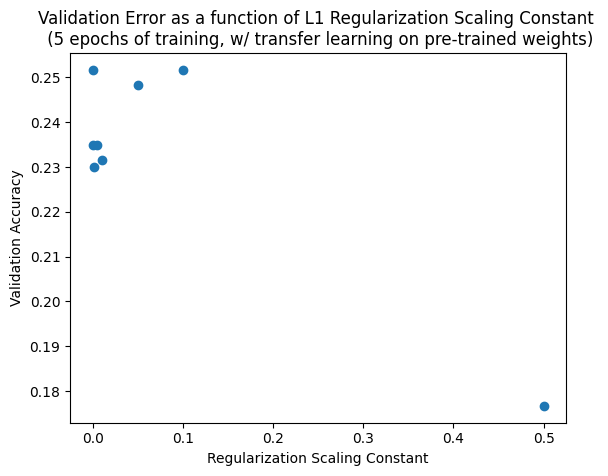

In [8]:
#L1 regularization scaling constant tuning - pretrained weights

import numpy as np 
import matplotlib.pyplot as plt 

results3 = np.array([[5.00000000e-01, 0.00000000e+00, 1.76666667e-01],
 [5.00000000e-01, 1.00000000e+00, 1.76666667e-01],
 [5.00000000e-01, 2.00000000e+00, 1.76666667e-01],
 [5.00000000e-01, 3.00000000e+00, 1.76666667e-01],
 [5.00000000e-01, 4.00000000e+00, 1.76666667e-01],
 [1.00000000e-01, 0.00000000e+00, 2.60000000e-01],
 [1.00000000e-01, 1.00000000e+00, 2.45000000e-01],
 [1.00000000e-01, 2.00000000e+00, 2.36666667e-01],
 [1.00000000e-01, 3.00000000e+00, 2.43333333e-01],
 [1.00000000e-01, 4.00000000e+00, 2.51666667e-01],
 [5.00000000e-02, 0.00000000e+00, 2.55000000e-01],
 [5.00000000e-02, 1.00000000e+00, 2.50000000e-01],
 [5.00000000e-02, 2.00000000e+00, 2.48333333e-01],
 [5.00000000e-02, 3.00000000e+00, 2.50000000e-01],
 [5.00000000e-02, 4.00000000e+00, 2.48333333e-01],
 [1.00000000e-02, 0.00000000e+00, 2.51666667e-01],
 [1.00000000e-02, 1.00000000e+00, 2.50000000e-01],
 [1.00000000e-02, 2.00000000e+00, 2.46666667e-01],
 [1.00000000e-02, 3.00000000e+00, 2.40000000e-01],
 [1.00000000e-02,4.00000000e+00, 2.31666667e-01],
 [5.00000000e-03, 0.00000000e+00, 2.38333333e-01],
 [5.00000000e-03, 1.00000000e+00, 2.43333333e-01],
 [5.00000000e-03, 2.00000000e+00, 2.26666667e-01],
 [5.00000000e-03, 3.00000000e+00, 2.46666667e-01],
 [5.00000000e-03, 4.00000000e+00, 2.35000000e-01],
 [1.00000000e-03, 0.00000000e+00, 2.40000000e-01],
 [1.00000000e-03, 1.00000000e+00, 2.35000000e-01],
 [1.00000000e-03, 2.00000000e+00, 2.35000000e-01],
 [1.00000000e-03, 3.00000000e+00, 2.43333333e-01],
 [1.00000000e-03, 4.00000000e+00, 2.30000000e-01],
 [5.00000000e-04, 0.00000000e+00, 2.40000000e-01],
 [5.00000000e-04, 1.00000000e+00, 2.46666667e-01],
 [5.00000000e-04, 2.00000000e+00, 2.33333333e-01],
 [5.00000000e-04, 3.00000000e+00, 2.38333333e-01],
 [5.00000000e-04, 4.00000000e+00, 2.35000000e-01],
 [1.00000000e-04, 0.00000000e+00, 2.41666667e-01],
 [1.00000000e-04, 1.00000000e+00, 2.43333333e-01],
 [1.00000000e-04, 2.00000000e+00, 2.36666667e-01],
 [1.00000000e-04, 3.00000000e+00, 2.46666667e-01],
 [1.00000000e-04, 4.00000000e+00, 2.51666667e-01]])


resultsData = results3[results3[:,1] == 4,:]

print(resultsData[:-1,:])
plt.scatter(resultsData[:,0],resultsData[:,2])
plt.title('Validation Error as a function of L1 Regularization Scaling Constant \n (5 epochs of training, w/ transfer learning on pre-trained weights)')
plt.xlabel('Regularization Scaling Constant')
plt.ylabel('Validation Accuracy')

In [7]:
#TEST PROCEDURE


correct = 0
visionTransformerModel.eval()

for i in testingSet:
    
    try:

        #-------------------------- TRANSFORMATIONS

        #get first image and label
        imageData = dataset[i][0]
        imageLabel = dataset[i][1]

        #print(imageLabel)
        #print(imageData)

        # [CITED DOCUMENTATION]
        # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
        # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

        #apply vit_transforms
        imageData = vit_transforms(imageData)

        '''
        #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
        imageData = np.array(imageData)
        height = image.shape[0]
        width = image.shape[1]
        layers = image.shape[2]
        image = image.reshape(layers, height,width)
        '''

        #convert to tensor
        imageData = torch.Tensor(imageData).to(cudaDevice)

        #additional transformation
        imageData = imageData.unsqueeze(0)
        imageData = imageData.float()

        #print(torch.Tensor.type(imageData))



        #-------------------------- FORWARD/BACKWARD PASSES


        #print('output')
        output = visionTransformerModel(imageData)
        prediction = torch.nn.functional.softmax(output)

        #[CITED DOCUMENTATION]
        # https://piazza.com/class/mkcrybcxyxq2ep/post/21


        if imageLabel.item() == torch.argmax(prediction).item():
            correct += 1

        print(imageLabel.item(),torch.argmax(prediction).item())
    
    except:
        None

        
print(correct/len(testingSet))





/scratch/4290674.1.academic-gpu/ipykernel_3250539/2890176894.py:52: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prediction = torch.nn.functional.softmax(output)


1 1
1 1
5 5
5 5
2 5
1 1
2 2
6 6
2 2
1 2
2 2
5 5
6 6
1 1
5 5
7 5
1 1
1 1
2 2
1 2
6 6
1 1
6 6
2 2
1 1
5 5
6 6
1 1
5 5
6 6
5 5
1 1
2 2
2 2
6 6
2 2
1 1
1 1
1 6
1 1
1 1
1 1
6 5
1 1
5 5
1 1
1 1
6 6
1 1
5 5
2 2
1 1
2 2
1 1
5 5
2 2
1 1
1 1
1 1
5 6
1 1
1 6
1 1
1 1
1 1
1 1
1 1
1 1
5 5
2 2
6 6
1 1
5 5
2 2
6 2
1 1
6 6
1 1
5 5
6 6
5 5
6 6
5 6
1 1
6 6
1 1
5 5
1 1
6 6
1 2
1 1
5 5
1 1
1 1
5 1
1 1
1 1
1 1
1 1
1 1
5 5
1 1
1 1
1 1
5 5
2 2
2 2
2 2
1 1
6 6
1 1
6 6
1 1
1 1
1 1
2 2
1 1
5 6
2 6
1 1
1 1
5 5
1 1
1 1
6 6
1 1
1 1
2 2
5 5
5 5
6 6
2 2
1 1
2 2
6 6
6 6
5 6
1 1
1 1
6 6
1 1
5 5
2 2
6 6
6 6
1 1
1 1
5 5
1 1
1 1
1 1
5 6
1 1
6 6
1 1
1 1
1 1
1 1
6 6
1 1
5 5
1 1
1 1
6 6
1 1
2 2
6 6
2 2
1 1
1 1
5 2
1 1
5 6
6 6
1 1
1 1
1 1
1 1
6 6
1 1
2 2
2 2
1 1
1 6
1 1
1 1
1 1
6 6
1 1
1 1
1 1
1 1
2 2
2 2
6 5
1 1
1 1
2 2
1 1
2 2
1 1
6 6
1 1
1 1
1 1
2 2
1 1
2 2
2 2
6 6
1 1
1 1
1 1
1 1
1 1
5 5
5 5
2 2
5 6
6 6
2 2
6 6
1 1
5 6
6 6
1 1
1 1
2 2
6 6
5 5
2 2
1 1
2 2
1 1
1 1
1 1
1 1
5 5
1 1
1 1
2 2
1 1
2 2
2 2
6 6
5 5
1 1
1 1
6 6
5 6


In [34]:
!nvidia-smi

Wed Mar 25 19:07:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-16GB           On  |   00000000:18:00.0 Off |                    0 |
| N/A   44C    P0             62W /  300W |    1062MiB /  16384MiB |      0%   E. Process |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Text(0, 0.5, 'Validation Accuracy')

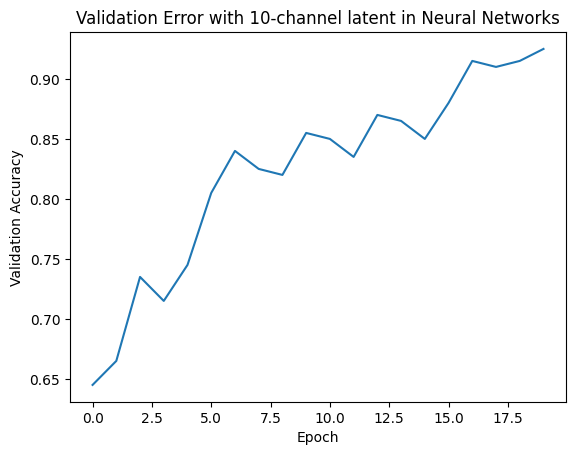

In [14]:
results = np.array([[1.00e-05, 0.00e+00, 6.45e-01],
 [1.00e-05, 1.00e+00, 6.65e-01],
 [1.00e-05, 2.00e+00, 7.35e-01],
 [1.00e-05, 3.00e+00, 7.15e-01],
 [1.00e-05, 4.00e+00, 7.45e-01],
 [1.00e-05, 5.00e+00, 8.05e-01],
 [1.00e-05, 6.00e+00, 8.40e-01],
 [1.00e-05, 7.00e+00, 8.25e-01],
 [1.00e-05, 8.00e+00, 8.20e-01],
 [1.00e-05, 9.00e+00, 8.55e-01],
 [1.00e-05, 1.00e+01, 8.50e-01],
 [1.00e-05, 1.10e+01, 8.35e-01],
 [1.00e-05, 1.20e+01, 8.70e-01],
 [1.00e-05, 1.30e+01, 8.65e-01],
 [1.00e-05, 1.40e+01, 8.50e-01],
 [1.00e-05, 1.50e+01, 8.80e-01],
 [1.00e-05, 1.60e+01, 9.15e-01],
 [1.00e-05, 1.70e+01, 9.10e-01],
 [1.00e-05, 1.80e+01, 9.15e-01],
 [1.00e-05, 1.90e+01, 9.25e-01]])


resultsData = results

plt.plot(resultsData[:,1],resultsData[:,2])
plt.title('Validation Error with 10-channel latent in Neural Networks')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')

In [8]:
#HP TUNING - BATCHES CONVERTED TO TENSORS - BATCH HP TUNING

#IMPLEMENTED WITH BATCH


cudaDevice = torch.device('cuda')

MOMENTUM = .8
EPOCHS = 5

batches = [1,5,10,50,100]





#local_path = "/content/drive/MyDrive/wadaba_local"
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local"
dataset = WadabaData(local_path)
TOTAL_LABELS = 8





#images that cause errors in the training process
bad_images = [1240,3399]


results = []

for batchValue in batches:
    
    BATCH_SIZE = batchValue
    LEARNING_RATE = .00001
    #LEARNING_RATE = learningRate
    
    #get pretrained weights
    #visionTransformerModelWeights = torchvision.models.ViT_B_16_Weights.DEFAULT
    #get associated transforms
    #visionTransformerModelTransforms = torchvision.models.ViT_B_16_Weights.DEFAULT.transforms
    #define model
    #visionTransformerModel = torchvision.models.vit_b_16(weights=visionTransformerModelWeights)
    visionTransformerModel = torchvision.models.vit_b_16()
    #got this idea from EC523 hmrk3 - adjusting output
    visionTransformerModel.heads.head = torch.nn.Linear(in_features=768,out_features=8)
    
    #declare loss function
    crossEntropyLoss = torch.nn.CrossEntropyLoss()

    #declare optimizer
    #"transfer learning" following the code from slide 105 in lecture "08_Training_II-3.pdf"
    optimizer = torch.optim.Adam(visionTransformerModel.parameters(),lr = LEARNING_RATE)

    
    visionTransformerModel.to(cudaDevice)

    for e in range(EPOCHS):

        print("EPOCH: ----------------------------- ", e,"out of",EPOCHS)
        visionTransformerModel.train()

        for i in range(0,len(trainingSet),BATCH_SIZE):


            #print("Epoch Progress: ",i/len(trainingSet))

            batch = torch.tensor([]).to(cudaDevice)
            batch_labels = torch.tensor([]).to(cudaDevice)
            
            for j in range(0,BATCH_SIZE):

                try:
                    #-------------------------- TRANSFORMATIONS

                    #[CITED DOCUMENTATION]
                    #looked up how to implement a "try" and "Except" workflow
                    #https://www.w3schools.com/python/python_try_except.asp

                    #get first image and label
                    imageData = dataset[trainingSet[i+j]][0]
                    imageLabel = dataset[trainingSet[i+j]][1]





                    #print("Training Image Index: ",trainingSet[i+j])

                    #print(imageData)

                    # [CITED DOCUMENTATION]
                    # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                    # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                    #apply vit_transforms
                    imageData = vit_transforms(imageData).to(cudaDevice)
                    imageLabel = torch.Tensor([imageLabel]).to(cudaDevice)




                    '''
                    #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                    imageData = np.array(imageData)
                    height = image.shape[0]
                    width = image.shape[1]
                    layers = image.shape[2]
                    image = image.reshape(layers, height,width)
                    '''

                    # [CITED DOCUMENATION]
                    #needed to convert tensor to numpy
                    #https://docs.pytorch.org/docs/stable/generated/torch.Tensor.numpy.html

                    #use torch.cat
                    batch = torch.cat((batch,imageData.unsqueeze(0)),0)
                    batch_labels = torch.cat((batch_labels,imageLabel),0)




                    #batch.append(imageData.numpy())
                    #batch_labels.append(imageLabel.numpy())
                except:
                    None

            
            try:

            
                #batch = np.array(batch)
                #batch_labels = np.array(batch_labels)

                #print(batch)
                #print(batch_labels)

                #convert to tensor
                imageData = torch.Tensor(batch).to(cudaDevice)



                #additional transformation
                #imageData = imageData.unsqueeze(0)
                imageData = imageData.float()


                #print(torch.Tensor.type(imageData))

                #print(imageData)
                #print(imageData.shape)

                #redefined the "dtype" attribute to an integer as shown in this documentation: https://docs.pytorch.org/docs/stable/tensor_attributes.html
                batch_labels = torch.tensor(batch_labels,dtype=torch.int)








            #-------------------------- FORWARD/BACKWARD PASSES


                #print('output')

                output = visionTransformerModel(imageData)
                #prediction = torch.nn.functional.softmax(output)
                prediction = output


                #[CITED DOCUMENTATION]
                # https://piazza.com/class/mkcrybcxyxq2ep/post/21

                #one hot label created similar to how Weicheng showed us

                #using torch.eye
                #https://docs.pytorch.org/docs/stable/generated/torch.eye.html
                identity = torch.eye(TOTAL_LABELS).to(cudaDevice)
                imageLabelOneHot = identity[batch_labels]

                #print(imageLabelOneHot.shape)
                #print(prediction.shape)


                #L1 optimization
                #I remember referring to this article to see how to implement regularization in pytorch code: https://medium.com/@arthur.lagacherie/understand-l1-and-l2-regularization-through-pytorch-code-ece84fe42ada
                loss = crossEntropyLoss(prediction,imageLabelOneHot) #+ learningRate*sum(sum(abs(visionTransformerModel.heads.head.weight)))
                #print(loss)

                #print(torch.sum(torch.abs(visionTransformerModel.heads.head.parameters())))


                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            except:
                None

        #print(visionTransformerModel.heads.head.weight)
        #print('done')
        correct = 0
        total = 0
        visionTransformerModel.eval()

        for i in validationSet:

            try: 
                #-------------------------- TRANSFORMATIONS

                #get first image and label
                imageData = dataset[i][0]
                imageLabel = dataset[i][1]

                #print(imageLabel)
                #print(imageData)

                # [CITED DOCUMENTATION]
                # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                #apply vit_transforms
                imageData = vit_transforms(imageData)

                '''
                #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                imageData = np.array(imageData)
                height = image.shape[0]
                width = image.shape[1]
                layers = image.shape[2]
                image = image.reshape(layers, height,width)
                '''

                #convert to tensor
                imageData = torch.Tensor(imageData).to(cudaDevice)

                #additional transformation
                imageData = imageData.unsqueeze(0)
                imageData = imageData.float()

                #print(torch.Tensor.type(imageData))

                #print(imageData.shape)



                #-------------------------- FORWARD/BACKWARD PASSES


                #print('output')
                output = visionTransformerModel(imageData)
                prediction = torch.nn.functional.softmax(output)

                #[CITED DOCUMENTATION]
                # https://piazza.com/class/mkcrybcxyxq2ep/post/21


                if imageLabel.item() == torch.argmax(prediction).item():
                    correct += 1
                
                total+=1

                print(imageLabel.item(),torch.argmax(prediction).item())

            except:
                None


        print(batchValue,e,(correct/total))
        results.append([batchValue,e,(correct/total)])
        
        print(np.array(results))







print('end of training')




EPOCH: -----------------------------  0 out of 5


/scratch/4290674.1.academic-gpu/ipykernel_3269778/3345701889.py:154: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch_labels = torch.tensor(batch_labels,dtype=torch.int)
/scratch/4290674.1.academic-gpu/ipykernel_3269778/3345701889.py:253: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prediction = torch.nn.functional.softmax(output)


1 1
6 2
2 2
1 1
2 2
2 1
1 1
2 2
7 1
1 1
1 6
1 1
5 6
1 1
1 1
6 6
1 1
2 1
1 1
1 2
1 1
2 2
5 6
5 1
2 2
1 1
5 6
2 2
1 1
2 2
2 2
1 1
2 2
6 6
5 1
6 6
6 6
1 1
1 1
6 6
6 1
1 1
2 6
5 6
6 2
1 1
7 6
2 1
1 6
5 6
1 1
5 6
1 1
5 2
6 2
5 6
2 2
1 1
1 2
1 1
1 1
2 6
5 6
1 1
1 1
5 6
1 6
2 2
1 1
5 6
5 6
1 1
5 6
1 1
1 1
1 1
1 1
2 6
1 2
1 1
1 1
6 2
1 1
6 2
1 1
2 6
1 1
1 1
1 1
2 6
1 1
1 1
1 1
1 1
5 1
2 2
2 2
5 2
2 6
6 2
1 2
1 6
1 1
1 1
1 1
1 1
1 1
1 6
1 1
6 6
1 1
5 1
1 1
6 1
5 1
1 1
6 2
1 1
1 1
2 1
1 1
1 1
2 2
2 6
1 1
6 6
1 1
5 2
1 2
5 6
1 1
5 6
1 1
1 1
5 6
2 2
1 1
1 1
1 2
1 1
1 1
6 2
5 6
2 2
1 1
1 1
1 1
1 1
5 1
2 2
1 1
1 6
1 1
5 2
1 1
2 2
1 1
1 1
6 6
1 1
1 1
1 1
1 1
5 2
1 2
1 1
6 6
1 1
1 1
1 1
5 1
2 2
5 6
5 1
1 1
1 1
7 6
1 1
5 6
1 1
6 1
7 1
1 1
5 6
6 1
2 2
1 1
6 2
1 1
6 2
2 2
1 1
1 1
5 6
1 1
1 1
1 1
2 1
1 1
6 6
1 0 0.62
[[1.   0.   0.62]]
EPOCH: -----------------------------  1 out of 5
1 1
6 2
2 1
1 1
2 2
2 1
1 1
2 2
7 6
1 1
1 1
1 1
5 6
1 1
1 1
6 6
1 1
2 2
1 1
1 2
1 1
2 2
5 6
5 1
2 2
1 1
5 2
2 2
1 1
2 2
2 2

1 1
5 5
1 1
2 2
1 2
1 1
6 6
1 5
1 1
1 1
1 1
5 6
1 2
1 6
6 6
1 1
1 1
1 1
5 2
2 2
5 6
5 5
1 1
1 5
7 5
1 1
5 6
1 1
6 6
7 5
1 1
5 5
6 6
2 2
1 1
6 6
1 1
6 6
2 2
1 1
1 1
5 6
1 1
1 1
1 1
2 6
1 1
6 5
5 3 0.705
[[1.    0.    0.62 ]
 [1.    1.    0.7  ]
 [1.    2.    0.74 ]
 [1.    3.    0.77 ]
 [1.    4.    0.795]
 [5.    0.    0.62 ]
 [5.    1.    0.715]
 [5.    2.    0.71 ]
 [5.    3.    0.705]]
EPOCH: -----------------------------  4 out of 5
1 1
6 2
2 2
1 6
2 2
2 2
1 1
2 2
7 6
1 1
1 5
1 1
5 6
1 1
1 1
6 5
1 1
2 2
1 1
1 2
1 1
2 2
5 5
5 5
2 2
1 1
5 5
2 2
1 1
2 2
2 2
1 1
2 2
6 6
5 5
6 6
6 6
1 5
1 1
6 6
6 5
1 5
2 2
5 5
6 6
1 5
7 5
2 2
1 1
5 2
1 2
5 5
1 1
5 2
6 6
5 5
2 2
1 1
1 2
1 1
1 1
2 6
5 5
1 1
1 1
5 5
1 5
2 2
1 1
5 6
5 5
1 1
5 5
1 5
1 1
1 1
1 1
2 2
1 1
1 5
1 1
6 2
1 1
6 6
1 1
2 6
1 1
1 1
1 5
2 2
1 1
1 1
1 1
1 5
5 5
2 2
2 2
5 6
2 2
6 2
1 1
1 5
1 5
1 1
1 5
1 1
1 1
1 2
1 1
6 6
1 1
5 5
1 1
6 6
5 2
1 1
6 6
1 1
1 1
2 2
1 5
1 1
2 2
2 5
1 6
6 6
1 1
5 2
1 1
5 6
1 1
5 5
1 1
1 5
5 6
2 2
1 1
1 1
1 1
1 1

1 1
6 1
2 1
1 1
2 1
2 1
1 1
2 2
7 1
1 1
1 1
1 1
5 1
1 1
1 1
6 1
1 1
2 1
1 1
1 1
1 1
2 1
5 1
5 1
2 1
1 1
5 1
2 1
1 1
2 1
2 1
1 1
2 1
6 1
5 1
6 1
6 1
1 1
1 1
6 1
6 1
1 1
2 1
5 1
6 1
1 1
7 1
2 1
1 1
5 1
1 1
5 1
1 1
5 1
6 1
5 1
2 1
1 1
1 1
1 1
1 1
2 1
5 1
1 1
1 1
5 1
1 1
2 1
1 1
5 1
5 1
1 1
5 1
1 1
1 1
1 1
1 1
2 1
1 1
1 1
1 1
6 1
1 1
6 6
1 1
2 1
1 1
1 1
1 1
2 1
1 1
1 1
1 1
1 1
5 1
2 1
2 1
5 1
2 1
6 1
1 1
1 1
1 1
1 1
1 1
1 1
1 1
1 1
1 1
6 1
1 1
5 1
1 1
6 1
5 1
1 1
6 1
1 1
1 1
2 1
1 1
1 1
2 1
2 1
1 1
6 1
1 1
5 1
1 1
5 1
1 1
5 1
1 1
1 1
5 1
2 1
1 1
1 1
1 2
1 1
1 1
6 1
5 1
2 1
1 1
1 1
1 1
1 1
5 1
2 1
1 1
1 1
1 1
5 1
1 1
2 1
1 1
1 1
6 1
1 1
1 1
1 1
1 1
5 1
1 1
1 1
6 1
1 1
1 1
1 1
5 1
2 1
5 1
5 1
1 1
1 1
7 1
1 1
5 1
1 1
6 1
7 1
1 1
5 1
6 1
2 1
1 1
6 6
1 1
6 2
2 1
1 1
1 1
5 1
1 1
1 1
1 1
2 1
1 1
6 1
50 1 0.54
[[ 1.     0.     0.62 ]
 [ 1.     1.     0.7  ]
 [ 1.     2.     0.74 ]
 [ 1.     3.     0.77 ]
 [ 1.     4.     0.795]
 [ 5.     0.     0.62 ]
 [ 5.     1.     0.715]
 [ 5.     2.     0.71 

2 1
1 1
5 1
2 6
1 1
2 1
2 1
1 1
2 1
6 1
5 1
6 1
6 1
1 1
1 1
6 1
6 1
1 1
2 1
5 1
6 1
1 1
7 1
2 1
1 1
5 1
1 1
5 1
1 1
5 1
6 1
5 1
2 1
1 1
1 1
1 1
1 1
2 1
5 1
1 1
1 1
5 1
1 1
2 1
1 1
5 1
5 1
1 1
5 1
1 1
1 1
1 1
1 1
2 1
1 1
1 1
1 1
6 1
1 1
6 6
1 1
2 1
1 1
1 1
1 1
2 1
1 1
1 1
1 1
1 1
5 1
2 1
2 1
5 1
2 1
6 1
1 1
1 1
1 1
1 1
1 1
1 1
1 1
1 1
1 1
6 1
1 1
5 1
1 1
6 1
5 1
1 1
6 2
1 1
1 1
2 1
1 1
1 1
2 1
2 1
1 1
6 1
1 1
5 1
1 1
5 1
1 1
5 1
1 1
1 1
5 1
2 2
1 1
1 1
1 2
1 1
1 1
6 1
5 1
2 1
1 1
1 1
1 1
1 1
5 1
2 1
1 1
1 1
1 1
5 1
1 1
2 1
1 1
1 1
6 1
1 1
1 1
1 1
1 1
5 1
1 1
1 1
6 1
1 1
1 1
1 1
5 1
2 1
5 1
5 1
1 1
1 1
7 1
1 1
5 1
1 1
6 1
7 1
1 1
5 1
6 1
2 1
1 1
6 6
1 1
6 2
2 1
1 1
1 1
5 1
1 1
1 1
1 1
2 1
1 1
6 1
100 2 0.545
[[  1.      0.      0.62 ]
 [  1.      1.      0.7  ]
 [  1.      2.      0.74 ]
 [  1.      3.      0.77 ]
 [  1.      4.      0.795]
 [  5.      0.      0.62 ]
 [  5.      1.      0.715]
 [  5.      2.      0.71 ]
 [  5.      3.      0.705]
 [  5.      4.      0.735]
 [ 10.      0.

[[  1.      4.      0.795]
 [  5.      4.      0.735]
 [ 10.      4.      0.73 ]
 [ 50.      4.      0.685]
 [100.      4.      0.595]]


Text(0, 0.5, 'Validation Accuracy')

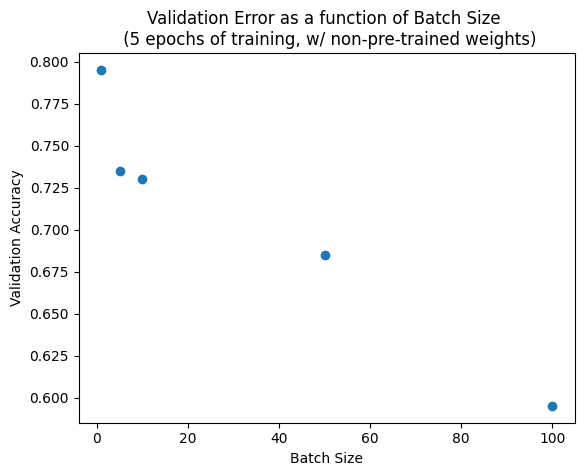

In [11]:
results = np.array([[  1.,      0.,      0.62 ],
 [  1.,      1.,      0.7  ],
 [  1.,      2.,      0.74 ],
 [  1.,      3.,      0.77 ],
 [  1.,      4.,      0.795],
 [  5.,      0.,      0.62 ],
 [  5.,      1.,      0.715],
 [  5.,      2.,      0.71 ],
 [  5.,      3.,      0.705],
 [  5.,      4.,      0.735],
 [ 10.,      0.,      0.62 ],
 [ 10.,      1.,      0.69 ],
 [ 10.,      2.,      0.69 ],
 [ 10.,      3.,      0.685],
 [ 10.,      4.,      0.73 ],
 [ 50.,      0.,      0.525],
 [ 50.,      1.,      0.54 ],
 [ 50.,      2.,      0.565],
 [ 50.,      3.,      0.65 ],
 [ 50.,      4.,      0.685],
 [100.,      0.,      0.54 ],
 [100.,      1.,      0.55 ],
 [100.,      2.,      0.545],
 [100.,      3.,      0.565],
 [100.,      4.,      0.595]])


resultsData = results[results[:,1] == 4,:]

print(resultsData[:,:])
plt.scatter(resultsData[:,0],resultsData[:,2])
plt.title('Validation Error as a function of Batch Size \n (5 epochs of training, w/ non-pre-trained weights)')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy')

In [122]:
#torch.cuda.is_available()

print(torch.version.cuda)

12.8


In [5]:
#HP TUNING - BATCHES CONVERTED TO TENSORS  - l1 regularization

#IMPLEMENTED WITH BATCH


cudaDevice = torch.device('cuda')

MOMENTUM = .8
EPOCHS = 5

l1_regularization = [.000001,.000005,.00001,.00005,.0001,.0005,.001,.005]






#local_path = "/content/drive/MyDrive/wadaba_local"
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local"
dataset = WadabaData(local_path)
TOTAL_LABELS = 8
BATCH_SIZE = 7




#images that cause errors in the training process
bad_images = [1240,3399]


results = []

for l1_alpha in l1_regularization:
    
    LEARNING_RATE = .00001
    #LEARNING_RATE = learningRate
    
    #get pretrained weights
    #visionTransformerModelWeights = torchvision.models.ViT_B_16_Weights.DEFAULT
    #get associated transforms
    #visionTransformerModelTransforms = torchvision.models.ViT_B_16_Weights.DEFAULT.transforms
    #define model
    #visionTransformerModel = torchvision.models.vit_b_16(weights=visionTransformerModelWeights)
    visionTransformerModel = torchvision.models.vit_b_16()
    #got this idea from EC523 hmrk3 - adjusting output
    visionTransformerModel.heads.head = torch.nn.Linear(in_features=768,out_features=8)
    
    #declare loss function
    crossEntropyLoss = torch.nn.CrossEntropyLoss()

    #declare optimizer
    #"transfer learning" following the code from slide 105 in lecture "08_Training_II-3.pdf"
    optimizer = torch.optim.Adam(visionTransformerModel.parameters(),lr = LEARNING_RATE)

    
    visionTransformerModel.to(cudaDevice)

    for e in range(EPOCHS):

        print("EPOCH: ----------------------------- ", e,"out of",EPOCHS)
        visionTransformerModel.train()

        for i in range(0,len(trainingSet),BATCH_SIZE):


            #print("Epoch Progress: ",i/len(trainingSet))

            batch = torch.tensor([]).to(cudaDevice)
            batch_labels = torch.tensor([]).to(cudaDevice)
            for j in range(0,BATCH_SIZE):

                try:
                    #-------------------------- TRANSFORMATIONS

                    #[CITED DOCUMENTATION]
                    #looked up how to implement a "try" and "Except" workflow
                    #https://www.w3schools.com/python/python_try_except.asp

                    #get first image and label
                    imageData = dataset[trainingSet[i+j]][0]
                    imageLabel = dataset[trainingSet[i+j]][1]





                    #print("Training Image Index: ",trainingSet[i+j])

                    #print(imageData)

                    # [CITED DOCUMENTATION]
                    # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                    # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                    #apply vit_transforms
                    imageData = vit_transforms(imageData).to(cudaDevice)
                    imageLabel = torch.Tensor([imageLabel]).to(cudaDevice)




                    '''
                    #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                    imageData = np.array(imageData)
                    height = image.shape[0]
                    width = image.shape[1]
                    layers = image.shape[2]
                    image = image.reshape(layers, height,width)
                    '''

                    # [CITED DOCUMENATION]
                    #needed to convert tensor to numpy
                    #https://docs.pytorch.org/docs/stable/generated/torch.Tensor.numpy.html

                    #use torch.cat
                    batch = torch.cat((batch,imageData.unsqueeze(0)),0)
                    batch_labels = torch.cat((batch_labels,imageLabel),0)




                    #batch.append(imageData.numpy())
                    #batch_labels.append(imageLabel.numpy())
                except:
                    None

  

            
            #batch = np.array(batch)
            #batch_labels = np.array(batch_labels)

            #print(batch)
            #print(batch_labels)

            #convert to tensor
            imageData = torch.Tensor(batch).to(cudaDevice)

            

            #additional transformation
            #imageData = imageData.unsqueeze(0)
            imageData = imageData.float()


            #print(torch.Tensor.type(imageData))

            #print(imageData)
            #print(imageData.shape)
            
            #redefined the "dtype" attribute to an integer as shown in this documentation: https://docs.pytorch.org/docs/stable/tensor_attributes.html
            batch_labels = torch.tensor(batch_labels,dtype=torch.int)








        #-------------------------- FORWARD/BACKWARD PASSES


            #print('output')

            output = visionTransformerModel(imageData)
            #prediction = torch.nn.functional.softmax(output)
            prediction = output


            #[CITED DOCUMENTATION]
            # https://piazza.com/class/mkcrybcxyxq2ep/post/21

            #one hot label created similar to how Weicheng showed us
            
            #using torch.eye
            #https://docs.pytorch.org/docs/stable/generated/torch.eye.html
            identity = torch.eye(TOTAL_LABELS).to(cudaDevice)
            imageLabelOneHot = identity[batch_labels]

            #print(imageLabelOneHot.shape)
            #print(prediction.shape)


            #L1 optimization
            #I remember referring to this article to see how to implement regularization in pytorch code: https://medium.com/@arthur.lagacherie/understand-l1-and-l2-regularization-through-pytorch-code-ece84fe42ada
            loss = crossEntropyLoss(prediction,imageLabelOneHot) + l1_alpha*sum(sum(abs(visionTransformerModel.heads.head.weight)))
            print(loss)
            
            #print(torch.sum(torch.abs(visionTransformerModel.heads.head.parameters())))


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        #print(visionTransformerModel.heads.head.weight)
        #print('done')
        correct = 0
        total = 0
        visionTransformerModel.eval()

        for i in validationSet:

            try: 
                #-------------------------- TRANSFORMATIONS

                #get first image and label
                imageData = dataset[i][0]
                imageLabel = dataset[i][1]

                #print(imageLabel)
                #print(imageData)

                # [CITED DOCUMENTATION]
                # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                #apply vit_transforms
                imageData = vit_transforms(imageData)

                '''
                #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                imageData = np.array(imageData)
                height = image.shape[0]
                width = image.shape[1]
                layers = image.shape[2]
                image = image.reshape(layers, height,width)
                '''

                #convert to tensor
                imageData = torch.Tensor(imageData).to(cudaDevice)

                #additional transformation
                imageData = imageData.unsqueeze(0)
                imageData = imageData.float()

                #print(torch.Tensor.type(imageData))

                #print(imageData.shape)



                #-------------------------- FORWARD/BACKWARD PASSES


                #print('output')
                output = visionTransformerModel(imageData)
                prediction = torch.nn.functional.softmax(output)

                #[CITED DOCUMENTATION]
                # https://piazza.com/class/mkcrybcxyxq2ep/post/21


                if imageLabel.item() == torch.argmax(prediction).item():
                    correct += 1
                
                total+=1

                print(imageLabel.item(),torch.argmax(prediction).item())

            except:
                None


        print(l1_alpha,e,(correct/total))
        results.append([l1_alpha,e,(correct/total)])
        
        print(np.array(results))







print('end of training')




EPOCH: -----------------------------  0 out of 5


/scratch/4290674.1.academic-gpu/ipykernel_3279285/1390010981.py:152: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch_labels = torch.tensor(batch_labels,dtype=torch.int)


tensor(2.6888, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.7177, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6241, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.5102, device='cuda:0', grad_fn=<AddBackward0>)
tensor(3.5543, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8121, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3954, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3165, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0271, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3455, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.5564, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.1270, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.4193, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0252, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.7981, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3573, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2296, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.1334, device='cuda:0', grad_fn=<AddBack

tensor(1.0660, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.5901, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6665, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0481, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0746, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.5093, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.4879, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0086, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2728, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.4500, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.6997, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3676, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.5111, device='cuda:0', grad_fn=<AddBackward0>)
tensor(2.1862, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9401, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8644, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2639, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3545, device='cuda:0', grad_fn=<AddBack

tensor(1.2441, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.5009, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.6261, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6716, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.9644, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8329, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8655, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.1665, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9948, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6103, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.1521, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9771, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0118, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.4843, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3453, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.8462, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0127, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.1306, device='cuda:0', grad_fn=<AddBack

...

tensor(0.9222, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.1248, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0774, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8306, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.8076, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8662, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0742, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2321, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0453, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9581, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9602, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6581, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3983, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8783, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0026, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8039, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6471, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2727, device='cuda:0', grad_fn=<AddBack

tensor(0.5699, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.1790, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8050, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0078, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8503, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.5488, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.7690, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.4812, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.5654, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3646, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3783, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6710, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3228, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9057, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.1426, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0227, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.5777, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2057, device='cuda:0', grad_fn=<AddBack

tensor(0.4399, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9143, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.7609, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.4549, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0406, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8641, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.1175, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2929, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.1449, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2790, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2717, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9055, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0157, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0944, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8847, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.6678, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9291, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.3745, device='cuda:0', grad_fn=<AddBack

tensor(1.1059, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.5516, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0060, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6223, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6185, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9470, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6633, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6511, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9817, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.5359, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.4880, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6338, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.7691, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8281, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8968, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.4946, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2085, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6135, device='cuda:0', grad_fn=<AddBack

tensor(1.0487, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.4451, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0978, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9747, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.2362, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.4626, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6617, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0003, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.8488, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.9163, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.5521, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6355, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.0393, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.7382, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.4523, device='cuda:0', grad_fn=<AddBackward0>)
1 1
6 2
2 2
1 6
2 5
2 2
1 1
2 2
7 6
1 1
1 5
1 1
5 6
1 1
1 1
6 6
1 1
2 2
1 1
1 2
1 1
2 2
5 6
5 5
2 2
1 1
5 2
2 2
1 1
2 2
2 2
1 1
2 2
6 5
5 1
6 6
6 6
1 1
1 1
6 6


In [ ]:

'''
L1 reg training numbers
[[1.00e-06 0.00e+00 6.15e-01]
 [1.00e-06 1.00e+00 6.40e-01]
 [1.00e-06 2.00e+00 7.20e-01]
 [1.00e-06 3.00e+00 7.30e-01]
 [1.00e-06 4.00e+00 7.65e-01]
 [5.00e-06 0.00e+00 6.10e-01]
 [5.00e-06 1.00e+00 6.70e-01]
 [5.00e-06 2.00e+00 6.45e-01]
 [5.00e-06 3.00e+00 6.90e-01]
 [5.00e-06 4.00e+00 7.65e-01]
 [1.00e-05 0.00e+00 6.25e-01]
 [1.00e-05 1.00e+00 6.85e-01]
 [1.00e-05 2.00e+00 7.10e-01]
 [1.00e-05 3.00e+00 6.40e-01]
 [1.00e-05 4.00e+00 7.55e-01]
 [5.00e-05 0.00e+00 6.45e-01]
 [5.00e-05 1.00e+00 7.00e-01]
 [5.00e-05 2.00e+00 6.85e-01]
 [5.00e-05 3.00e+00 6.85e-01]
 [5.00e-05 4.00e+00 7.80e-01]
 [1.00e-04 0.00e+00 6.15e-01]
 [1.00e-04 1.00e+00 6.55e-01]
 [1.00e-04 2.00e+00 6.80e-01]
 [1.00e-04 3.00e+00 7.55e-01]
 [1.00e-04 4.00e+00 7.35e-01]
 [5.00e-04 0.00e+00 6.25e-01]
 [5.00e-04 1.00e+00 6.70e-01]
 [5.00e-04 2.00e+00 7.20e-01]
 [5.00e-04 3.00e+00 7.55e-01]
 [5.00e-04 4.00e+00 7.25e-01]
 [1.00e-03 0.00e+00 6.05e-01]
 [1.00e-03 1.00e+00 7.00e-01]
 [1.00e-03 2.00e+00 7.10e-01]
 [1.00e-03 3.00e+00 7.40e-01]
 [1.00e-03 4.00e+00 7.95e-01]
 [5.00e-03 0.00e+00 5.45e-01]
 [5.00e-03 1.00e+00 6.60e-01]
 [5.00e-03 2.00e+00 7.45e-01]
 [5.00e-03 3.00e+00 8.05e-01]
 [5.00e-03 4.00e+00 8.00e-01]]
 '''

In [ ]:
#OLD CODE: test image runthrough

test_image = "/content/drive/MyDrive/wadaba_local/0099_a02b01c1d1e0f1g0h4.jpg"

testTensor = torchvision.io.read_image(test_image)
testTensor = testTensor.unsqueeze(0)
testTensor = testTensor.float()


# [CITED DOCUMENTATION]
# https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
# https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

#declare transforms
changeSize = torchvision.transforms.Resize((224,224))
normValues = torchvision.transforms.Normalize((120,120,120),(1,1,1))

testTensor = changeSize(testTensor)
testTensor = normValues(testTensor)

print(testTensor)
print(testTensor.shape)

print('output')
output = visionTransformerModel(testTensor)
prediction = torch.nn.functional.softmax(output)

testLabel = 4
total_labels = 1000

#[CITED DOCUMENTATION]
# https://piazza.com/class/mkcrybcxyxq2ep/post/21

#one hot label created similar to how Weicheng showed us
testLabelOneHot = torch.Tensor(np.eye(total_labels)[testLabel]).unsqueeze(0)

print(testLabelOneHot.shape)
print(prediction.shape)

loss = crossEntropyLoss(testLabelOneHot,prediction)

optimizer.zero_grad()
loss.backward()
optimizer.step()


#print(torch.argmax(prediction))


